- 미션 소개
    - Hugging Face transformers 라이브러리를 사용하여 문서 요약 모델을 구현하는 미션입니다. 데이터 로드 및 전처리부터 요약 모델 실행, 결과 평가까지 전체 파이프라인을 구축해 보세요.

- 사용 데이터셋
    - 먼저 이번 미션에 사용할 데이터 셋을 다운로드 받아주세요. (약 0.4GB)

    - 데이터 형식: JSON 파일 형태로 제공되며, 3종류(신문 기사, 사설, 법률)의 문서가 포함되어 있습니다.

    - 데이터 구성: 각 문서 타입은 train/test 쌍으로 구성되어 있으며, 전체 데이터를 모두 사용하거나 원하는 문서 종류를 선택하여 학습시키면 됩니다.

- 가이드라인
    1. 데이터 로드 및 전처리
        - 문서 데이터를 로드하고, 불필요한 기호나 공백을 제거하는 등 전처리 작업을 수행합니다.
        - 텍스트 길이를 확인하고, 모델 입력에 적합한 형식으로 변환합니다.
    2. 모델 선택 및 실행
        - Hugging Face의 transformers 라이브러리를 활용해 문서 요약을 수행합니다.
        - 사전 학습된 모델을 활용하거나 주어진 데이터를 가지고 Fine-tuning을 해 보세요.
    3. 모델 평가 및 결과 분석
        - 생성된 요약문과 원본 문서를 비교하여 ROUGE 등의 평가 지표를 사용해 요약 품질을 분석합니다.
        - 테스트 문장에 대한 요약 결과를 출력하여 모델의 성능을 확인합니다.
    4. 마크다운 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운 셀을 통해 간결하게 기록하세요.
        - 코드와 결과를 한눈에 이해할 수 있도록 전체 워크플로우를 체계적으로 정리해 주세요.

- 제출안내
    1. 모델 구현 및 학습 결과
        - 문서 요약 모델(예: Transformer 기반 요약 모델, T5, BART 등)을 구현하고, 데이터 로드 → 전처리 → 모델 구축 및 학습 → 요약 생성 및 평가 과정을 순차적으로 진행하세요.
    2. 마크다운을 활용한 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
        - 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.
    3. 모델 성능 평가 및 제출
        - 생성된 요약문의 품질을 정성적(요약 결과 확인) 및 정량적(ROUGE 등, optional)으로 평가해 보세요.
        - 테스트 데이터셋에 대한 요약 결과를 포함해 주세요.

- 참고 사항
    - 미션을 시작할 때 도움이 필요하다면, Baseline 코드를 참고할 수 있습니다. 이 코드는 기본적인 코드로 제공되며, 여러분이 원하는 대로 자유롭게 변형할 수 있어요.
        - Baseline 코드 링크
        - 주의 사항: Baseline 코드는 여러분이 모델을 시작하는 데 도움을 주기 위한 참고 자료일 뿐이며, Baseline 코드를 그대로 사용하는 것보다는 이를 기반으로 자신의 아이디어를 추가하고 발전시키는 것이 중요합니다. 가능하면 스스로 모델을 구축해보고 다양한 방법을 시도하여 성능을 향상시켜 보세요.
    - 원본 데이터셋 링크
        - AI HUB 문서요약 텍스트

# 0. 연구결과 및 결론

### 1. 데이터

- **데이터셋**: 한국어 법률 도메인 요약 데이터셋 (`train_original_law.json`, `valid_original_law.json`)
    - 훈련 샘플 수: 약 24,000개
    - 검증 샘플 수: 약 3,000개
- **전처리**:
    - 문장 단위로 합쳐 전체 문서(`full`) 구성
    - 요약(`summary`)은 `abstractive` 중 첫 문장 사용
    - 특수전처리는 시행하지 않음
    - SentencePiece BPE 모델(`spm.SentencePieceTrainer`)로 토크나이징
        - user_defined_symbols: `[MASK]`, `[CLS]`, `[SEP]`
- **문장 최대 길이**:
    - full 텍스트 기준 95% 백분위수로 설정 (길이 값은 config에 저장됨)
- **임베딩**:
    - `nn.Embedding` 사용
    - 임베딩 차원(`d_model`)은 config로 지정 (예: 256)

---

### 2. 데이터 분할

- **훈련:검증:시험 = 80:20:고정**
- **Train**: 80% (`train_val_ratio = 0.8`)
- **Validation**: 20%
- **Test**: 별도 제공된 `valid_original_law.json`에서 1,000개 추출

---

### 3. 모델 구조

- **선택 모델**: `EnhancedMiniBART`
    - **인코더**: TransformerEncoder (`nn.TransformerEncoderLayer × num_layers`)
    - **디코더**: TransformerDecoder (`nn.TransformerDecoderLayer × num_layers`)
    - **추가 구성**:
        - 위치 인코딩 (`PositionalEncoding`)
        - FFN에 Gating Layer 추가 (`FeedForwardWithGating`)
- **출력**: Linear → vocab_size projection
- **입력 포맷**:
    - src = `[BOS] full [EOS]`
    - tgt = `[BOS] summary [EOS]`
- **마스크**:
    - pad 마스크 및 causal 마스크(tgt)

---

### 4. 하이퍼파라미터 분석

- **튜닝 방식**: WANDB sweep
- **사용된 설정 예시**:
    
    ```python
    sweep_config = {
        "method": "bayes",
        "metric": {
            "name": "valid/loss",
            "goal": "minimize"
        },
        "parameters": {
            "d_model": {"values": [192, 256, 320]},
            "nhead": {"values": [2, 3, 4]},
            "num_layers": {"values": [1, 2, 3]},
            "dropout": {"values": [0.3, 0.4, 0.5]},
            "lr": {"values": [5e-5, 1e-4, 3e-4]},
            "label_smoothing": {"values": [0.0, 0.1]},
            "weight_decay": {"values": [0.0, 1e-5, 1e-4]},
            "batch_size": {"values": [4, 8, 16]},
            "optimizer": {"values": ["AdamW"]},
            "scheduler": {"values": ["ROP", "CosineAnnealingLR"]},
            "criterion": {"values": ["CrossEntropyLoss", "NLLLoss"]}
        }
    }
    ```
---

### 5. 학습 방식

- **훈련 루프**:
    - 각 에폭마다 `train_one_epoch` → `validate_one_epoch` 순서로 실행
    - 매 스텝마다 다음을 수행:
        1. 입력: full 문장 (`[BOS] + full + [EOS]`)
        2. 출력: summary 문장 (`[BOS] + summary + [EOS]`)
        3. 디코더 입력은 `summary`에서 마지막 토큰 제거 (teacher forcing)
        4. 디코더 라벨은 `summary`에서 첫 토큰 제거
    - 로스 계산:
        - `CrossEntropyLoss` 또는 `NLLLoss`
        - `ignore_index = pad`, `label_smoothing` 옵션 적용 가능
        - 로스는 non-PAD 토큰에 대해서만 계산
    - 옵티마이저 및 스케줄러:
        - Optimizer: AdamW (weight_decay 포함)
        - Scheduler: `CosineAnnealingLR` 또는 `ReduceLROnPlateau` 등
    - 그레이디언트 클리핑: `grad_clip` 설정값 사용 (예: 1.0)
- **평가지표**:
    - **Accuracy**: 정답 토큰과 예측 토큰의 정확도
    - **Perplexity**: exp(loss), 모델의 불확실성 척도
- **검증/조기 종료**:
    - 검증셋 성능 기준으로 `Early Stopping` 적용 (`patience` 설정)
    - 가장 낮은 `valid_loss` 기준으로 모델 저장
    - 동일 loss일 경우, `accuracy` 높은 모델 선택
- **Test 평가**:
    - 훈련 종료 후 best model 로딩
    - 테스트셋에 대해 loss, accuracy, perplexity 평가
    - 5개 샘플에 대해 예측 결과 출력: 원문, 정답 요약, 예측 요약
- **로깅**:
    - 선택적으로 `Weights & Biases` 사용 가능 (`use_wandb=True`)
    - 학습/검증/시험 결과, 러닝레이트, 예시 결과 로그 자동 기록

---

### 6. 결과

- 최적 하이퍼파라미터 (W&B Sweep 결과)
    - **배치 크기**: `batch_size = 4`
    - **손실 함수**: `criterion = CrossEntropyLoss`
    - **임베딩 차원**: `d_model = 192`
    - **드롭아웃**: `dropout = 0.3`
    - **라벨 스무딩**: `label_smoothing = 0.1`
    - **학습률**: `lr = 0.0001`
    - **어텐션 헤드 수**: `nhead = 3`
    - **인코더/디코더 층 수**: `num_layers = 1`
    - **최적화 함수**: `optimizer = AdamW`
    - **러닝레이트 스케줄러**: `scheduler = CosineAnnealingLR`
    - **가중치 감쇠**: `weight_decay = 1e-5`
```lua

```
Epoch 01
├─ Train | Loss: 8.3891 | Acc: 0.0912 | PPL: 4398.73 | LR: 5.0e-04 | Time: 5145.5s
├─ Valid | Loss: 7.9798 | Acc: 0.1208 | PPL: 2921.40 | Time: 560.2s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

Epoch 02
├─ Train | Loss: 7.7768 | Acc: 0.1193 | PPL: 2384.70 | LR: 4.8e-04 | Time: 5358.6s
├─ Valid | Loss: 7.6737 | Acc: 0.1353 | PPL: 2151.02 | Time: 553.4s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

Epoch 03
├─ Train | Loss: 7.4732 | Acc: 0.1293 | PPL: 1760.17 | LR: 4.1e-04 | Time: 4965.5s
├─ Valid | Loss: 7.5570 | Acc: 0.1419 | PPL: 1914.00 | Time: 465.0s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

Epoch 04
├─ Train | Loss: 7.2725 | Acc: 0.1356 | PPL: 1440.18 | LR: 3.1e-04 | Time: 4394.7s
├─ Valid | Loss: 7.4729 | Acc: 0.1468 | PPL: 1759.64 | Time: 450.3s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

Epoch 05
├─ Train | Loss: 7.1264 | Acc: 0.1400 | PPL: 1244.45 | LR: 1.9e-04 | Time: 4470.2s
├─ Valid | Loss: 7.4288 | Acc: 0.1502 | PPL: 1683.86 | Time: 450.3s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

Epoch 06
├─ Train | Loss: 7.0253 | Acc: 0.1439 | PPL: 1124.68 | LR: 9.5e-05 | Time: 4473.0s
├─ Valid | Loss: 7.4252 | Acc: 0.1518 | PPL: 1677.70 | Time: 450.1s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

Epoch 07
├─ Train | Loss: 6.9677 | Acc: 0.1458 | PPL: 1061.74 | LR: 2.6e-05 | Time: 4472.4s
├─ Valid | Loss: 7.4093 | Acc: 0.1526 | PPL: 1651.29 | Time: 449.9s
└─ Best Model Updated at ./checkpoints\EnhancedMiniBART_best_250422_192230.pt!

[Test Summary]
- Loss       : 7.3665
- Accuracy   : 0.1567
- Perplexity : 1582.08
- Time       : 91.1s

[Sample Predictions]
Input  : [1] 항고소송의 대상이 되는 행정처분이라 함은 원칙적으로 행정청의 공법상 행위로서 특정 사항에 대하여 법규에 의한 권리의 설정 또는 의무의 부담을 명하거나 기타 법률상 효과를 발생하게 하는 등으로 일반 국민의 권리의무에 직접 영향을 미치는 행위를 가리키는 것이지만, 어떠한 처분의 근거가 행정규칙에 규정되어 있다고 하더라도, 그 처분이 상대방에게 권리의 설정 또는 의무의 부담을 명하거나 기타 법적인 효과를 발생하게 하는 등으로 그 상대방의 권리의무에 직접 영향을 미치는 행위라면, 이 경우에도 항고소송의 대상이 되는 행정처분에 해당한다. [2] 정부 간 항공노선의 개설에 관한 잠정협정 및 비밀양해각서와 건설교통부 내부지침에 의한 항공노선에 대한 운수권배분처분이 항고소송의 대상이 되는 행정처분에 해당한다고 한 사례. [3] 행정행위를 한 처분청은 비록 그 처분 당시에 별다른 하자가 없었고, 또 그 처분 후에 이를 철회할 별도의 법적 근거가 없다 하더라도 원래의 처분을 존속시킬 필요가 없게 된 사정변경이 생겼거나 또는 중대한 공익상의 필요가 발생한 경우에는 그 효력을 상실케 하는 별개의 행정행위로 이를 철회할 수 있다고 할 것이나, 수익적 행정처분을 취소 또는 철회하는 경우에는 이미 부여된 그 국민의 기득권을 침해하는 것이 되므로, 비록 취소 등의 사유가 있다고 하더라도 그 취소권 등의 행사는 기득권의 침해를 정당화할 만한 중대한 공익상의 필요 또는 제3자의 이익보호의 필요가 있는 때에 한하여 상대방이 받는 불이익과 비교·교량하여 결정하여야 하고, 그 처분으로 인하여 공익상의 필요보다 상대방이 받게 되는 불이익 등이 막대한 경우에는 재량권의 한계를 일탈한 것으로서 그 자체가 위법하다.
Target : 항고소송의 대상이 되는 행정처분이란 일반 국민의 권리의무에 직접 영향을 미치는 행위를 가리키는 것으로, 정부 간 항공노선의 개설에 관한 잠정협정 및 비밀양해각서와 건설교통부 내부지침에 의한 항공노선에 대한 운수권배분처분은 항고소송의 대상이 되는 행정처분에 해당하고, 그 처분으로 인해 공익상의 필요에 비해 상대방이 받게 되는 불이익 등이 더욱 큰 경우에는 재량권의 한계를 일탈한 것으로서 그 자체가 위법하다.
Output : 구 대상이 되는 행정처분이 아니고 그 수요자나 권리의무에 있어서 상대방이 미칠 영향 한 경우, 그,암의조,되어 대한 법률등급, 그,도로 온이 그 대한지와위임 대한 동의를에의 관한 관계에서과 행사의분실 적법하다 대상이 되는 것은 해당한다, 그 후 인한 발생한 필요가 의한 현저히 그 되는 것은에 있은 엄격하게 것은 그 일탈 일탈한 것이다 위법하다 후 아니다. 한 것은 것으로 것으로 것으로 이유로 이유로이다이다의의의의의의.......... 한다 한다 한다 위 위 위 한다 한다 한다 한다 한다 제 한다 한다 한다 한다에에에가 한다.. 해당하지...... 해당하지 해당하지 대한 대한 있었다고 위법하다고 위법하다고 위법하다고 위법하다고..에에 해당하지 원칙에 원칙에의의를를한한한 못한 못한 못한 못한 못한 못한한 않은 않은에에,,조한한한재산을재산을재산을재산을 수 수, 있는 있는 있는 점 원칙에 원칙에 원칙에 있는 있는 있는 경우 경우 경우 이유로를 될 될 한 한 한 한 하는 그 제 제 한 한 한 한 하는 하는 하는 제 제 그 그 위 위 볼 볼 볼 볼 볼 볼 볼 볼 인정된다 인정된다 그 그 될 될 될 될 될 될 그 그 그 않는다 볼 그 아니다 아니다 아니다 아니다 아니다 것은 그 그 그 그 그 그 그 것은 그 그 그 그 그 그 그 그 그 바 바 것으로 한 한 된 된 할 할 할를.. 할 그지는지는지는 있는금금금',,,,,,,,,,,,,,,,,,, 있는,,,,,,, 그,,, 있는 있는 그 그 그 그 있는 있는 있는세세, 있는 있는 그 그 그 그 것은 것으로 그 그 그에에에가가가,,,,,,,,가가가가가 것이 것이지는가가가가 등의 등의 등의 등의,, 수 수 수 수,,,,지는지는지는지는가가가가 수 경우 경우 경우 경우 경우''가 한 한 한 한 한 한 한 경우 경우 경우 한 한 한 한 한 한 한 한 한 한 한 이익이 이익이 이익이 이익이 위지는지는지는하는지는,,,,,,,,,가가가가 할,,,,,가가,,,,,,,,'' 반환을작작다죄가죄가에가가가에에에에에에에에에에지는지는지는,,,,,로가가,,,,로로로가가가에에에에에에에에에에
```

```
---

### 6. 결론

- [https://wandb.ai/joungyoungsun20-/text-summary?nw=nwuserjoungyoungsun20]
- 사전 훈련된 모델이 아니고, GPU의 제약으로 CPU만 사용해 결과가 매우 좋지 않았다.
- Loss도 매우 높으며, 생성한 문장은 전혀 말이 되지 않았다.
- 이미지를 처리하던 것과 다르게 Full-Scratch방식으로 LLM을 하게 되면, 결과가 좋지 않다는 것을 느꼈다.
- 오히려 잘 정리된 데이터에서 실행할 과제가 많다는 것을 깨달았다. (분류, 생성, 등등)
- 그에 반해 사전 훈련된 Hugging Face를 사용하니 고작 300개으 데이터만으로도 훌륭하게 결과물을 만들어냈다. 조금 허탈하다.
- BERT구조를 사용해 요약문에 주요하게 영향을 끼친 문장들을 고르는 과제(NSP)와 마스킹된 글자를 예측하는 과제(MLM)를 시험해보았다. 역시 결과는 좋지 않았다.

## 문서요약 실험 구조 (법률 도메인 기준)

### 1. 데이터 전처리

```
prepare_data_and_tokenizer(config)
├── load_category_dataset()
│   └── JSON 로드: train_original_law.json / valid_original_law.json
├── save_dataset_as_csv()
│   └── CSV 저장: train_law.csv / valid_law.csv
├── save_text_for_spm()
│   └── SentencePiece 학습용 corpus 저장: full + summary
├── train_sp_model()
│   └── SentencePiece BPE 학습 및 vocab/model 생성
├── get_max_len()
│   └── 토큰 길이 통계로 max_len 설정 (95% 커버 기준)

```

### 2. 데이터로더 생성

```
get_all_loaders(train_df, valid_df, config)
├── split_train_validation()
│   └── train:valid = 8:2 분할
├── Full2SummaryDataset
│   └── input: [BOS] full [EOS]
│   └── target: [BOS] summary [EOS]
├── collate_fn()
│   └── input_ids / input_mask / target_ids 텐서 반환
├── DataLoader 생성 (sample_size)
│   ├── train_loader
│   ├── valid_loader
│   └── test_loader

```

### 3. 모델 구성

```
get_model(config)
└── EnhancedMiniBART (선택 모델)
    ├── Embedding + PositionalEncoding
    ├── Encoder: TransformerEncoder × num_layers
    ├── Decoder: TransformerDecoder × num_layers
    ├── Fusion: FeedForwardWithGating
    └── Output: Linear to vocab

```

### 4. 학습 구성

```
run(model, train_loader, valid_loader, test_loader, sp, config)
├── wandb.init()
├── train()
│   ├── get_optimizer() → AdamW(lr=5e-4)
│   ├── get_scheduler() → CosineAnnealingLR(epochs=5)
│   ├── get_criterion() → CrossEntropyLoss(ignore_index=pad, label_smoothing=0.1)
│   ├── for epoch in range(epochs):
│   │   ├── train_one_epoch()
│   │   ├── validate_one_epoch()
│   │   ├── scheduler.step()
│   │   ├── 모델 저장 조건:
│   │   │   └── valid_loss 개선 or loss 동률 + acc 개선
│   │   └── early stopping (patience=3)
│   └── best_model_path 저장
├── evaluate()
│   ├── best 모델 평가
│   ├── 예시 src / tgt / pred 수집 (최대 5개)
│   └── loss / acc / ppl 계산
└── wandb.finish()

```

### 5. 주요 설정 (config)

```
경로 및 데이터
├── base_path: data 경로
├── category: law
├── train_val_ratio: 0.8
├── train_sample_size: 1000
├── test_sample_size: 100

토크나이저
├── sp_vocab_size: 32000
├── coverage_ratio: 0.95

모델
├── model_name: EnhancedMiniBART
├── d_model: 256
├── nhead: 4
├── num_layers: 2
├── dropout: 0.3

학습
├── batch_size: 4
├── epochs: 5
├── patience: 3
├── lr: 5e-4
├── weight_decay: 1e-5
├── grad_clip: 1.0

최적화
├── optimizer: AdamW
├── scheduler: CosineAnnealingLR
├── criterion: CrossEntropyLoss + label_smoothing(0.1)

기타
├── device: cpu
├── save_dir: ./checkpoints
├── use_wandb: True

```

---

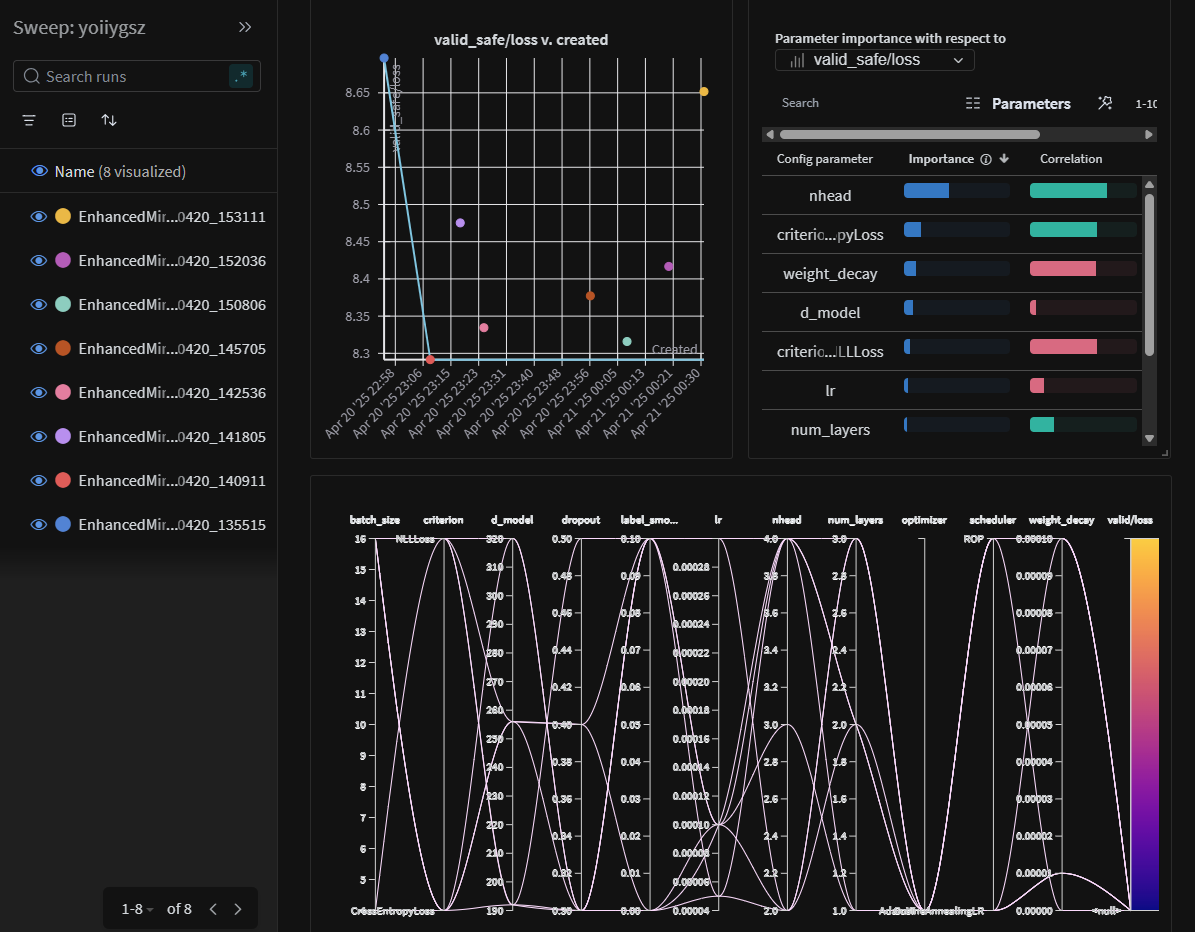

# 준비사항

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install datasets
!pip install konlpy

# 1.데이터 불러오기

## data_utils.py

In [1]:
import os
import json
import pandas as pd
import numpy as np
import re
import sentencepiece as spm

def load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)

    data = []
    max_col_len = 0

    for doc in json_data["documents"]:
        sentences = []
        for sublist in doc["text"]:
            for item in sublist:
                sentences.append(item.get("sentence", ""))

        sent_len = len(sentences)
        max_col_len = max(max_col_len, sent_len)

        summary = doc["abstractive"][0] if doc["abstractive"] else ""

        entry = {i: s for i, s in enumerate(sentences)}
        entry["max_len"] = sent_len
        entry["full"] = " ".join(sentences)
        entry["summary"] = summary
        data.append(entry)

    df = pd.DataFrame(data)
    columns = list(range(max_col_len)) + ["max_len", "full", "summary"]
    df = df.reindex(columns=columns)

    return df


def load_category_dataset(config):
    train_json = f"train_original_{config['category']}.json"
    valid_json = f"valid_original_{config['category']}.json"
    train_path = os.path.join(config["base_path"], train_json)
    valid_path = os.path.join(config["base_path"], valid_json)

    train_df = load_json(train_path)
    valid_df = load_json(valid_path)

    config.update({
        "train_json_path": train_path,
        "valid_json_path": valid_path,
    })
    print(f"1. config updated with JSON paths!")
    return train_df, valid_df, config


def save_dataset_as_csv(train_df, valid_df, config):
    data_dir = os.path.join(config["base_path"], "data")
    os.makedirs(data_dir, exist_ok=True)

    train_path = os.path.join(data_dir, f"train_{config['category']}.csv")
    valid_path = os.path.join(data_dir, f"valid_{config['category']}.csv")

    if os.path.exists(train_path) and os.path.exists(valid_path):
        print(f"    - CSVs already exist. Skipping save.")
    else:
        train_df.to_csv(train_path, index=False)
        valid_df.to_csv(valid_path, index=False)
        print(f"    - Saved CSVs →\n  train: {train_path}\n  valid: {valid_path}")

    config.update({
        "train_csv_path": train_path,
        "valid_csv_path": valid_path,
    })
    print(f"2. Saved CSVs and updated config paths!")
    return config


def save_text_for_spm(train_df, config):
    bpe_dir = os.path.join(config["base_path"], "bpe")
    os.makedirs(bpe_dir, exist_ok=True)

    corpus_path = os.path.join(bpe_dir, f"corpus_{config['category']}.txt")

    if os.path.exists(corpus_path):
        print(f"    - Corpus file already exists. Skipping save.")
    else:
        with open(corpus_path, "w", encoding="utf-8") as f:
            for _, row in train_df.iterrows():
                f.write(str(row["full"]).strip() + "\n")
                f.write(str(row["summary"]).strip() + "\n")
        print(f"    - Saved corpus → {corpus_path}")

    config.update({"sp_corpus_path": corpus_path})
    print(f"3. Saved corpus and updated config!")
    return config


def train_sp_model(config):
    corpus_path = config["sp_corpus_path"]
    model_prefix = os.path.join(config["base_path"], "bpe", f"spm_{config['category']}")
    model_path = f"{model_prefix}.model"
    vocab_path = f"{model_prefix}.vocab"

    if os.path.exists(model_path) and os.path.exists(vocab_path):
        print(f"    - SentencePiece model already exists. Skipping training.")
    else:
        spm.SentencePieceTrainer.Train(
            input=config["sp_corpus_path"],
            model_prefix=model_prefix,
            vocab_size=config["sp_vocab_size"],
            character_coverage=1.0,
            model_type="bpe",
            pad_id=0,
            unk_id=1,
            bos_id=2,
            eos_id=3,
            user_defined_symbols=["[MASK]", "[CLS]", "[SEP]"]
        )
        print(f"    - Trained SentencePiece model → {model_path}")

    sp = spm.SentencePieceProcessor(model_file=f"{model_prefix}.model")
    actual_vocab_size = sp.get_piece_size()

    config.update({
        "sp_model_path": model_path,
        "sp_vocab_path": vocab_path,
        "sp_vocab_size": actual_vocab_size,
        "pad": 0,
        "unk": 1,
        "bos": 2,
        "eos": 3,
    })
    print(f"4. Trained SentencePiece and updated config!")
    return config


def get_max_len(train_df, config):
    sp = spm.SentencePieceProcessor()
    sp.load(config["sp_model_path"])

    # 각 문장의 토큰 개수만 수집
    token_lengths = [len(sp.encode_as_ids(str(text).strip())) for text in train_df["full"]]

    # 원하는 커버리지에 해당하는 토큰 길이 계산
    coverage_percentile = config.get("coverage_ratio", 0.95) * 100
    max_len = int(np.percentile(token_lengths, coverage_percentile))
    print(f"    - {coverage_percentile:.1f}% of samples are <= {max_len} tokens")

    config.update({"max_len": max_len})
    print(f"5. Updated config with SentencePiece token coverage length.")
    return config



def prepare_data_and_tokenizer(config):
    train_df, valid_df, config = load_category_dataset(config)
    config = save_dataset_as_csv(train_df, valid_df, config)
    config = save_text_for_spm(train_df, config)
    config = train_sp_model(config)
    config = get_max_len(train_df, config)
    print(f"6. All preparation steps completed.")
    return train_df, valid_df, config


In [ ]:
config = {
    "base_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/",
    "category": "law",      # "news", "editorial", "law"

    # SentencePiece 설정
    "sp_vocab_size": 32000,
    "coverage_ratio": 0.95,
}

In [ ]:
def print_config(config):
    print("\nConfig Summary")
    print("────────────────────────────")
    for k, v in config.items():
        print(f"{k}: {v}")
    print("────────────────────────────\n")

In [ ]:
train_law_df, valid_law_df, config = prepare_data_and_tokenizer(config)

1. config updated with JSON paths!
    - CSVs already exist. Skipping save.
2. Saved CSVs and updated config paths!
    - Corpus file already exists. Skipping save.
3. Saved corpus and updated config!
    - SentencePiece model already exists. Skipping training.
4. Trained SentencePiece and updated config!
    - 95.0% of samples are <= 509 tokens
5. Updated config with SentencePiece token coverage length.
6. All preparation steps completed.


In [ ]:
print_config(config)


Config Summary
────────────────────────────
base_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/
category: law
sp_vocab_size: 32000
coverage_ratio: 0.95
train_json_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/train_original_law.json
valid_json_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/valid_original_law.json
train_csv_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/data/train_law.csv
valid_csv_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/data/valid_law.csv
sp_corpus_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/corpus_law.txt
sp_model_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/spm_law.model
sp_vocab_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/spm_law.vocab
pad: 0
unk: 1
bos: 2
eos: 3
max_len: 509
────────────────────────────



### 데이터 살펴보기

In [ ]:
train_law_df.describe()

,max_len
count,24329.000000
mean,9.937153
std,6.667112
min,4.000000
25%,5.000000
50%,7.000000
75%,12.000000
max,50.000000


In [ ]:
train_law_df.head(1)

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,max_len,full,summary
0,원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인 근무를 해...,"노조조합장이 사임한 경우,",노동조합규약에 동 조합장의 직무를 대행할 자를 규정해 두고 있음에도 원고 자신이 주...,종업원들에게도 나쁜 영향을 끼쳐 소속회사가 취업규칙을 위반하고,고의로 회사업무능률을 저해하였으며 회사업무상의 지휘명령에 위반하였음을 이유로 원고를...,이는 원고의 노동조합 활동과는 관계없이 회사취업규칙에 의하여 사내질서를 유지하기 위...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인 근무를 해...,원고가 주동하여 회사업무능률을 저해하고 회사업무상의 지휘명령에 위반하였다면 이에 ...


In [ ]:
train_law_df[train_law_df[49].notna()].head(1)

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,max_len,full,summary
3711,가. 한국외환은행이 수급인인 건설회사의 보증의뢰에 따라 도급인인 사우디아라비아 왕국...,보증의뢰인의 어떤 반대에도 불구하고,"즉시 수익자가 청구하는 보증금을 지급하겠다는 것이라면,",그 의무의 성질이 무조건적이고,"보증인이 주장할 수 있는 어떠한 면책사유로도 대항하지 않겠다는 것임이 분명하므로,","이는 주채무에 대한 관계에 있어서 부종성을 지니는 통상의 보증이 아니라,",주채무자(보증의뢰인)와 채권자(수익자) 사이의 원인관계와는 독립되어 그 원인관계에 ...,수익자의 청구가 있기만 하면,보증인의 무조건적인 지급의무가 발생하게 되는 이른바 독립적 은행보증(first de...,따라서 이러한 은행보증의 보증인으로서는 수익자의 청구가 있기만 하면,...,독립적 은행보증에 있어서 보증의뢰인과 보증은행 사이에 체결된 보증의뢰계약에서 보증의...,보증의뢰인이 수익자의 권리남용임이 명백한 보증금 청구에 대하여자신의 권리를 신속하게...,물론 보증은행의 입장에서 볼 때 비교적 간이한 소명방법이 허용되는 가처분절차에 의하...,나중에 그 가처분이 부당한 것으로 판명됨에 따라 보증은행이 대외적인 신용에 있어 손...,이는 수익자의 보증금 청구가 명백히 권리남용에 해당하여 무효라는 충분한 소명이 있는...,가처분 신청권 자체를 부정하여 그 직접적인 이해당사자인 보증의뢰인으로 하여금 사법상...,그 부제소특약의 약관조항은 같은 법 제14조의 규정에 따라 무효라고 해석함이 옳을 ...,50,가. 한국외환은행이 수급인인 건설회사의 보증의뢰에 따라 도급인인 사우디아라비아 왕국...,보증인의 무조건적인 지급의무가 발생하는 독립적 은행보증에 있어서 보증의뢰인과 보증은...


In [ ]:
valid_law_df.describe()

,max_len
count,3004.000000
mean,7.807590
std,5.469462
min,4.000000
25%,4.000000
50%,6.000000
75%,9.000000
max,49.000000


In [ ]:
valid_law_df.head(1)

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,max_len,full,summary
0,"[1] 취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고,",처분 등이 있은 날부터 1년을 경과하면,"제기하지 못하며( 행정소송법 제20조 제1항, 제2항), 청구취지를 변경하여 구 소...",[2] 일반적으로 행정처분에 효력기간이 정하여져 있는 경우에는 그 기간의 경과로 그...,다만 허가에 붙은 기한이 그 허가된 사업의 성질상 부당하게 짧은 경우에는 이를 그 ...,"[3] 사도개설허가에서 정해진 공사기간 내에 사도로 준공검사를 받지 못한 경우,",이 공사기간을 사도개설허가 자체의 존속기간(유효기간)으로 볼 수 없다는 이유로 사도...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,"[1] 취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고, 처분...","취소소송은 처분 등이 있다는 것을 안 때로부터 90일 이내에 제기하여야 하고, 행정..."


In [ ]:
valid_law_df[valid_law_df[48].notna()].head(1)

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,max_len,full,summary
768,[1] 주식회사의 외부감사에 관한 법률은 위 법 제2조에서 정한 주식회사는 제13조...,위 회계처리기준을 위반하여 허위의 재무제표를 작성·공시하는 행위를 각종 행정제재 및...,위 법 제2조에서 정한 주식회사의 여신 신청을 심사하는 금융기관으로서는 특별한 사정...,따라서 주식회사가 위 법률의 회계처리기준이 개정되었으나,그 부칙 조항에 따라 아직 개정 전 회계처리기준이 적용되어야 하는 회계연도 재무제표...,"이를 분명하게 주석 처리하는 등의 방법으로 명시하지 아니하고,",이와 같이 편법을 사용하여 작성된 재무제표를 금융기관에 제출하게 되면,금융기관으로서는 원래 해당 회계연도에 적용되는 개정 전 회계처리기준에 의하여 위 재...,이는 해당 회계연도의 회사 재무상황에 대하여 금융기관의 착오를 일으키는 것이어서,기망행위에 해당한다.,...,구 예금자보호법(2003. 5. 29. 법률 제6891호로 개정되기 전의 것) 제2...,[12] 금융기관이 행한 여신이 기망행위로 인한 착오에 기인한 것인지 여부는 해당 ...,그에 관한 증명책임은 검사에게 있다.,[13] 배임죄가 성립하기 위해서는 행위자의 임무위배행위로 인하여 본인에게 재산상 ...,회사가 행한 대출의 실질이 자금 이동 없는 서류상의 채무자 변경에 불과하고,실질적인 담보력에 변화가 없어 이로 인하여 대출 채권을 회수하지 못할 위험이 발생하...,그 대출행위는 배임죄를 구성한다고 볼 수 없다.,49,[1] 주식회사의 외부감사에 관한 법률은 위 법 제2조에서 정한 주식회사는 제13조...,강제집행을 하려는 자에 대해 재산을 발견하지 못하게 또는 곤란하게 하는 은닉등의 행...


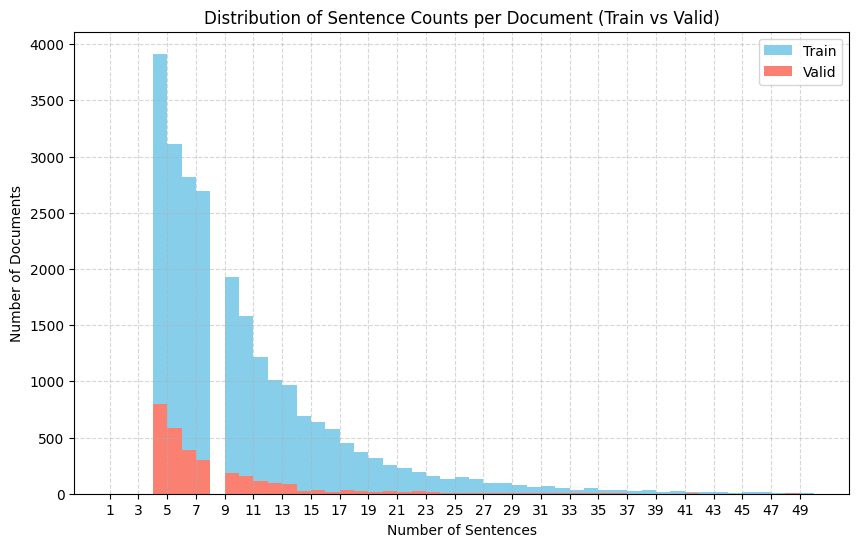

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bins = range(1, 51)
plt.hist(train_law_df["max_len"], bins=bins, label="Train", color="skyblue")
bins= range(1, 50)
plt.hist(valid_law_df["max_len"], bins=bins, label="Valid", color="salmon")

plt.title("Distribution of Sentence Counts per Document (Train vs Valid)")
plt.xlabel("Number of Sentences")
plt.ylabel("Number of Documents")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(range(1, 51, 2))
plt.show()

토큰 길이 최대값: 1382
토큰 길이 평균값: 216.32
토큰 길이 중앙값: 173.0
95% 이하 구간: 509.0


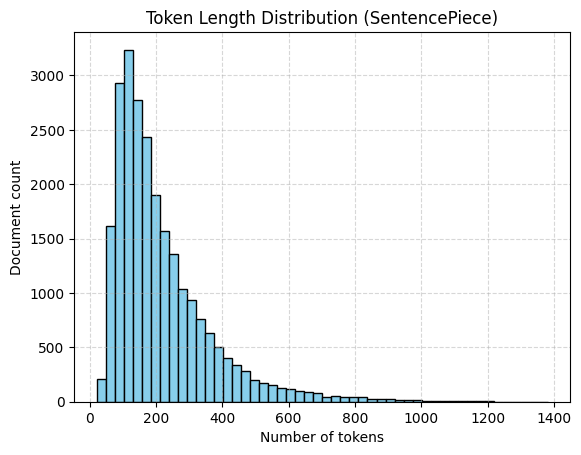

In [ ]:
sp = spm.SentencePieceProcessor()
sp.load(config["sp_model_path"])

token_lengths = train_law_df["full"].apply(lambda x: len(sp.encode(x, out_type=int)))

# 통계 출력
print(f"토큰 길이 최대값: {token_lengths.max()}")
print(f"토큰 길이 평균값: {token_lengths.mean():.2f}")
print(f"토큰 길이 중앙값: {token_lengths.median()}")
print(f"95% 이하 구간: {token_lengths.quantile(0.95)}")

# 시각화
plt.hist(token_lengths, bins=50, color="skyblue", edgecolor="black")
plt.title("Token Length Distribution (SentencePiece)")
plt.xlabel("Number of tokens")
plt.ylabel("Document count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## loader.py

In [ ]:
import torch
from torch.utils.data import Dataset
import sentencepiece as spm

class Full2SummaryDataset(Dataset):
    def __init__(self, df, sp, max_len):
        self.df = df
        self.sp = sp
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def pad_or_truncate(self, ids):
        ids = ids[:self.max_len]
        return ids + [0] * (self.max_len - len(ids))

    def __getitem__(self, idx):
        full = self.df.iloc[idx]["full"]
        summary = self.df.iloc[idx]["summary"]

        # 입력: BOS full EOS / BOS summary EOS
        input_ids = [self.sp.bos_id()] + self.sp.encode_as_ids(full) + [self.sp.eos_id()]
        target_ids = [self.sp.bos_id()] + self.sp.encode_as_ids(summary) + [self.sp.eos_id()]

        input_ids = self.pad_or_truncate(input_ids)
        target_ids = self.pad_or_truncate(target_ids)

        # 마스크
        input_mask = [t != 0 for t in input_ids]

        return torch.tensor(input_ids), torch.tensor(input_mask), torch.tensor(target_ids)


from sklearn.model_selection import train_test_split

def split_train_validation(train_df, config):
    test_size = 1 - config["train_val_ratio"]
    train_df, valid_df = train_test_split(
        train_df,
        test_size=test_size,
        random_state=config["seed"],
        shuffle=True
    )
    print(f"    - Train Val Ratio: {config['train_val_ratio']:.1f}: {test_size:.1f}")
    print(f"    - Train: {len(train_df)}, Valid: {len(valid_df)}")
    return train_df.reset_index(drop=True), valid_df.reset_index(drop=True)


def collate_fn(batch):
    input_ids, input_mask, target_ids = zip(*batch)

    input_ids = torch.stack(input_ids)
    input_mask = torch.stack(input_mask)
    target_ids = torch.stack(target_ids)

    return {
        "input_ids": input_ids,
        "input_mask": input_mask,
        "target_ids": target_ids,
    }


from torch.utils.data import DataLoader

def get_all_loaders(train_df, test_df, config):
    # 샘플 수 제한
    train_sample_size = config.get("train_sample_size", None)
    if train_sample_size:
        train_df = train_df[:train_sample_size]
    test_sample_size = config.get("test_sample_size", None)
    if test_sample_size:
        test_df = test_df[:test_sample_size]

    train_df, valid_df = split_train_validation(train_df, config)
    sp = spm.SentencePieceProcessor(model_file=config["sp_model_path"])

    train_loader = DataLoader(
        Full2SummaryDataset(train_df, sp, config["max_len"]),
        batch_size=config["batch_size"],
        shuffle=True,
        collate_fn=collate_fn
    )
    valid_loader = DataLoader(
        Full2SummaryDataset(valid_df, sp, config["max_len"]),
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        Full2SummaryDataset(test_df, sp, config["max_len"]),
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=collate_fn
    )

    if config.get("verbose", 0) > 0:
        print("\nDataLoader Summary")
        print("─────────────────────────────")
        for name, loader in zip(["Train", "Valid", "Test"], [train_loader, valid_loader, test_loader]):
            sample_count = len(loader.dataset)
            batch_count = len(loader)
            print(f"[{name}] Samples: {sample_count} | Batches: {batch_count}")
            batch = next(iter(loader))
            for k, v in batch.items():
                print(f"    {k:<12} shape: {tuple(v.shape)}")
        print("─────────────────────────────\n")

    return train_loader, valid_loader, test_loader

In [ ]:
config.update({
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "train_val_ratio": 0.8,
    "seed": 42,
    "verbose": 1,
    "train_sample_size": 1000,
    "test_sample_size": 100,
    "batch_size": 4,
})

In [ ]:
train_loader, valid_loader, test_loader = get_all_loaders(train_law_df, valid_law_df, config)

    - Train Val Ratio: 0.8: 0.2
    - Train: 800, Valid: 200

DataLoader Summary
─────────────────────────────
[Train] Samples: 800 | Batches: 200
    input_ids    shape: (4, 509)
    input_mask   shape: (4, 509)
    target_ids   shape: (4, 509)
[Valid] Samples: 200 | Batches: 50
    input_ids    shape: (4, 509)
    input_mask   shape: (4, 509)
    target_ids   shape: (4, 509)
[Test] Samples: 100 | Batches: 25
    input_ids    shape: (4, 509)
    input_mask   shape: (4, 509)
    target_ids   shape: (4, 509)
─────────────────────────────



In [ ]:
print_config(config)


Config Summary
────────────────────────────
base_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/
category: law
sp_vocab_size: 32000
coverage_ratio: 0.95
train_json_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/train_original_law.json
valid_json_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/valid_original_law.json
train_csv_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/data/train_law.csv
valid_csv_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/data/valid_law.csv
sp_corpus_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/corpus_law.txt
sp_model_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/spm_law.model
sp_vocab_path: /content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/spm_law.vocab
pad: 0
unk: 1
bos: 2
eos: 3
max_len: 509
device: cpu
train_val_ratio: 0.8
seed: 42
verbose: 1
train_sample_size: 1000
test_sample_size: 100
batch_size: 4
────────

# 2.학습준비

## model.py

In [ ]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)  # (T, D)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # (T, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))  # (D/2, )
        pe[:, 0::2] = torch.cos(position * div_term)    # even idx
        pe[:, 1::2] = torch.sin(position * div_term)    # odd idx
        pe = pe.unsqueeze(0)    # (1, T, D)
        self.register_buffer('pe', pe)

    def forward(self, x):
        seq_len = x.size(1)
        if seq_len > self.pe.size(1):
            raise ValueError(f"[ERROR] Input sequence length {seq_len} exceeds positional encoding max_len {self.pe.size(1)}")
        return x + self.pe[:, :seq_len]


class MiniBART(nn.Module):
    def __init__(self, vocab_size, pad_id, d_model=512, nhead=8, num_layers=3, max_len=512, dropout=0.1):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.embed_ln = nn.LayerNorm(d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.pos_enc = PositionalEncoding(d_model, max_len)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True
        )

        self.out_ln = nn.LayerNorm(d_model)
        self.out_dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, size):
        # 상삼각 True 마스크 (causal mask)
        mask = torch.triu(torch.ones(size, size, dtype=torch.bool), diagonal=1)
        return mask

    def make_pad_mask(self, seq):
        # 패딩 마스크 생성
        return (seq == self.pad_id)

    def forward(self, src, tgt, src_mask=None):
        """
        src: (B, S), input 문장 (full)
        tgt: (B, T), 요약 문장 (summary)
        """

        if src_mask is None:
            src_pad_mask = self.make_pad_mask(src)  # (B, S)
        else:
            src_pad_mask = src_mask.bool()
        tgt_pad_mask = self.make_pad_mask(tgt)  # (B, T)
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)  # (T, T)

        # 임베딩 + 위치 인코딩
        src_emb = self.embed_dropout(self.embed_ln(self.pos_enc(self.embed(src))))  # (B, S, D)
        tgt_emb = self.embed_dropout(self.embed_ln(self.pos_enc(self.embed(tgt))))  # (B, T, D)

        output = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )  # (B, T, D)

        output = self.out_dropout(self.out_ln(output))
        return self.out_proj(output)  # (B, T, vocab_size)


class FeedForwardWithGating(nn.Module):
    def __init__(self, d_model, hidden_dim, dropout):
        super().__init__()
        self.linear1 = nn.Linear(d_model, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, d_model)
        self.gate = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        hidden = self.activation(self.linear1(x))
        hidden = self.dropout(self.linear2(hidden))
        gate = torch.sigmoid(self.gate(x))
        out = hidden * gate + x
        return self.norm(out)


class EnhancedMiniBART(nn.Module):
    def __init__(self, vocab_size, pad_id, d_model=512, nhead=8, num_layers=3, max_len=512, dropout=0.1):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.embed_ln = nn.LayerNorm(d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.pos_enc = PositionalEncoding(d_model, max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=2048,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=2048,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fusion_ffn = FeedForwardWithGating(d_model, d_model * 4, dropout)


        self.encoder_ln = nn.LayerNorm(d_model)
        self.decoder_ln = nn.LayerNorm(d_model)
        self.out_ln = nn.LayerNorm(d_model)
        self.out_dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, size):
        return torch.triu(torch.ones(size, size, dtype=torch.bool), diagonal=1)

    def make_pad_mask(self, seq):
        return seq == self.pad_id

    def forward(self, src, tgt, src_mask=None):
        if src_mask is None:
            src_pad_mask = self.make_pad_mask(src)
        else:
            src_pad_mask = src_mask.bool()
        tgt_pad_mask = self.make_pad_mask(tgt)
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        src_emb = self.embed_dropout(self.embed_ln(self.pos_enc(self.embed(src))))
        tgt_emb = self.embed_dropout(self.embed_ln(self.pos_enc(self.embed(tgt))))

        memory = self.encoder(src_emb, src_key_padding_mask=src_pad_mask)
        memory = self.encoder_ln(memory)

        output = self.decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )
        output = self.decoder_ln(output)

        output = self.fusion_ffn(output)
        output = self.out_ln(self.out_dropout(output))
        return self.out_proj(output)


def get_model(config):
    if config["model_name"] == "MiniBART":
        model = MiniBART(
            vocab_size=config["sp_vocab_size"],
            pad_id=config["pad"],
            d_model=config["d_model"],
            nhead=config["nhead"],
            num_layers=config["num_layers"],
            max_len=config["max_len"],
            dropout=config["dropout"]
        )
        return model.to(config["device"])
    elif config["model_name"] == "EnhancedMiniBART":
        model = EnhancedMiniBART(
            vocab_size=config["sp_vocab_size"],
            pad_id=config["pad"],
            d_model=config["d_model"],
            nhead=config["nhead"],
            num_layers=config["num_layers"],
            max_len=config["max_len"],
            dropout=config["dropout"]
        )
        return model.to(config["device"])
    else:
        raise ValueError(f"Unsupported model: {config['model_name']}")


def get_sp(config):
    sp = spm.SentencePieceProcessor()
    sp.load(config["sp_model_path"])
    return sp

```
src → Embedding+PE → Encoder → LN → memory
tgt → Embedding+PE → Decoder(tgt_mask+attn) + memory → LN
→ Fusion FFN (Gating) → LN+Dropout → Linear → output(logits)
```

In [ ]:
model = EnhancedMiniBART(
    vocab_size=config["sp_vocab_size"],
    pad_id=config["pad"]
).to(config["device"])

model.eval()

with torch.no_grad():
    for batch in train_loader:
        inp = batch["input_ids"].to(config["device"])     # (B, S)
        mask = batch["input_mask"].to(config["device"])   # (B, S)
        tgt = batch["target_ids"].to(config["device"])    # (B, T)

        print("==== Batch Debug Info ====")
        print(f"[input_ids]       shape: {inp.shape} | dtype: {inp.dtype} | pad token count: {(inp == config['pad']).sum().item()}")
        print(f"[input_mask]      shape: {mask.shape} | sum(mask): {mask.sum().item()}")
        print(f"[target_ids]      shape: {tgt.shape} | dtype: {tgt.dtype} | BOS count: {(tgt == config['bos']).sum().item()}")

        out = model(inp, tgt)  # (B, T, vocab_size)

        print(f"[model output]    shape: {out.shape} | dtype: {out.dtype}")
        print(f"[vocab_size]      expected: {config['sp_vocab_size']} | output_dim: {out.shape[-1]}")
        print(f"[first token logits] (batch 0):\n{out[0, 0, :5]} ...")  # 첫 번째 토큰의 앞 5개 logits
        print("==============================\n")
        break  # 한 배치만 확인

==== Batch Debug Info ====
[input_ids]       shape: torch.Size([4, 509]) | dtype: torch.int64 | pad token count: 1546
[input_mask]      shape: torch.Size([4, 509]) | sum(mask): 490
[target_ids]      shape: torch.Size([4, 509]) | dtype: torch.int64 | BOS count: 4


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[model output]    shape: torch.Size([4, 509, 32000]) | dtype: torch.float32
[vocab_size]      expected: 32000 | output_dim: 32000
[first token logits] (batch 0):
tensor([-7.5808e-01,  5.5695e-04, -6.3101e-02, -5.0249e-01, -3.2072e-01]) ...



## utils.py

In [ ]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

def get_optimizer(model, config):
    opt_name = config["optimizer"]
    lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.0)

    if opt_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "AdamW":
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=config.get("momentum", 0.9), weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")



def get_scheduler(optimizer, config):
    name = config["scheduler"]

    if name == "ROP":
        return lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=config.get("factor", 0.5),
            patience=config.get("patience", 3),
            min_lr=config.get("min_lr", 1e-6)
        )
    elif name == "CosineAnnealingLR":
        return lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config["epochs"],
            eta_min=config.get("min_lr", 1e-6)
        )
    elif name == "CosineAnnealingWarmRestarts":
        return lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=config.get("T_0", 3),
            T_mult=config.get("T_mult", 1),
            eta_min=config.get("min_lr", 1e-6)
        )
    else:
        raise ValueError(f"Unsupported scheduler: {name}")


def get_criterion(config):
    if config["criterion"] == "CrossEntropyLoss":
        return nn.CrossEntropyLoss(
            ignore_index=config["pad"],
            label_smoothing=config.get("label_smoothing", 0.0)
        )
    elif config["criterion"] == "NLLLoss":
        return nn.NLLLoss(ignore_index=config["pad"])
    else:
        raise ValueError(f"Unsupported criterion: {config['criterion']}")

## train.py

In [ ]:
import torch
import torch.nn as nn
import wandb
from tqdm import tqdm
import os
from time import time

def train_one_epoch(model, dataloader, optimizer, criterion, config, epoch):
    model.train()
    total_loss = 0
    total_tokens = 0
    correct_tokens = 0
    start_time = time()

    pbar = tqdm(dataloader, desc=f"[Train] Epoch {epoch+1}", leave=False)

    for batch in pbar:
        src = batch["input_ids"].to(config["device"])         # (B, S)
        src_mask = batch["input_mask"].to(config["device"])   # (B, S), bool
        tgt = batch["target_ids"].to(config["device"])        # (B, T)

        tgt_in = tgt[:, :-1]   # decoder input
        tgt_out = tgt[:, 1:]   # decoder output (label)

        optimizer.zero_grad()
        logits = model(src, tgt_in, src_mask)  # (B, T, vocab_size)

        if config["criterion"] == "NLLLoss":
            import torch.nn.functional as F
            logits = F.log_softmax(logits.clamp(min=-10, max=10), dim=-1)

        num_tokens = (tgt_out != config["pad"]).sum().item()
        if num_tokens == 0:
            print(f"[DEBUG - Train] All tokens are PAD.")
            print(f"[DEBUG] tgt_out unique tokens: {torch.unique(tgt_out)}")
            print(f"[DEBUG] pad token: {config['pad']}")
            continue

        loss = criterion(
            logits.contiguous().view(-1, logits.size(-1)),
            tgt_out.contiguous().view(-1)
        )
        loss.backward()

        if config.get("grad_clip", 0.0) > 0.0:
            nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])

        optimizer.step()

        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

        pred = logits.argmax(dim=-1)
        correct = ((pred == tgt_out) * (tgt_out != config["pad"]))
        correct_tokens += correct.sum().item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct.sum().item() / num_tokens:.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.7f}"
        })

    avg_loss = total_loss / total_tokens
    avg_acc = correct_tokens / total_tokens
    ppl = torch.exp(torch.tensor(avg_loss)).item()
    elapsed_time = time() - start_time

    if config.get("use_wandb", False):
        wandb.log({
            "train/loss": avg_loss,
            "train/acc": avg_acc,
            "train/ppl": ppl,
            "train/lr": optimizer.param_groups[0]["lr"],
            "train/time": elapsed_time
        })

    # print(f"[Epoch {epoch+1:02d}] Train Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f} | PPL: {ppl:.2f} | Time: {elapsed_time:.1f}s")
    return avg_loss, avg_acc, ppl, elapsed_time


def validate_one_epoch(model, dataloader, criterion, config, epoch):
    model.eval()
    total_loss = 0
    total_tokens = 0
    correct_tokens = 0
    start_time = time()

    pbar = tqdm(dataloader, desc=f"[Valid] Epoch {epoch+1}", leave=False)

    with torch.no_grad():
        for batch in pbar:
            src = batch["input_ids"].to(config["device"])         # (B, S)
            src_mask = batch["input_mask"].to(config["device"])   # (B, S)
            tgt = batch["target_ids"].to(config["device"])        # (B, T)

            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            logits = model(src, tgt_in, src_mask)

            if config["criterion"] == "NLLLoss":
                import torch.nn.functional as F
                logits = F.log_softmax(logits.clamp(min=-10, max=10), dim=-1)

            num_tokens = (tgt_out != config["pad"]).sum().item()
            if num_tokens == 0:
                print(f"[DEBUG - Valid] All tokens are PAD.")
                print(f"[DEBUG] tgt_out unique tokens: {torch.unique(tgt_out)}")
                print(f"[DEBUG] pad token: {config['pad']}")
                continue

            loss = criterion(
                logits.contiguous().view(-1, logits.size(-1)),
                tgt_out.contiguous().view(-1)
            )

            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

            pred = logits.argmax(dim=-1)
            correct = ((pred == tgt_out) * (tgt_out != config["pad"]))
            correct_tokens += correct.sum().item()

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{correct.sum().item() / num_tokens:.4f}",
            })

    avg_loss = total_loss / total_tokens
    accuracy = correct_tokens / total_tokens
    ppl = torch.exp(torch.tensor(avg_loss)).item()  # perplexity
    elapsed_time = time() - start_time

    if config.get("use_wandb", False):
        wandb.log({
            "valid/loss": avg_loss,
            "valid/acc": accuracy,
            "valid/ppl": ppl,
            "valid/time": elapsed_time,
        })

    # print(f"[Epoch {epoch+1:02d}] Valid Loss: {avg_loss:.4f} | Acc: {accuracy:.4f} | PPL: {ppl:.2f} | Time: {elapsed_time:.1f}s")
    if total_tokens == 0:
        print(f"[Epoch {epoch+1}] Warning: No valid tokens in validation set — skipping loss/accuracy computation.")
        return float("inf"), 0.0, float("inf"), elapsed_time

    return avg_loss, accuracy, ppl, elapsed_time


def safe_validate_one_epoch(model, dataloader, criterion, config, epoch):
    model.eval()
    total_loss = 0
    total_tokens = 0
    correct_tokens = 0
    start_time = time()

    pbar = tqdm(dataloader, desc=f"[Valid-Safe] Epoch {epoch+1}", leave=False)

    with torch.no_grad():
        for batch in pbar:
            src = batch["input_ids"].to(config["device"])
            src_mask = batch["input_mask"].to(config["device"])
            tgt = batch["target_ids"].to(config["device"])

            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            logits = model(src, tgt_in, src_mask)

            if config["criterion"] == "NLLLoss":
                import torch.nn.functional as F
                logits = F.log_softmax(logits.clamp(min=-10, max=10), dim=-1)

            num_tokens = (tgt_out != config["pad"]).sum().item()
            if num_tokens == 0:
                if config.get("verbose", 1) > 0:
                    print(f"[DEBUG] [Valid-Safe] Skipping batch with all PAD tokens.")
                continue

            loss = criterion(
                logits.contiguous().view(-1, logits.size(-1)),
                tgt_out.contiguous().view(-1)
            )

            loss_val = loss.item()
            if not torch.isfinite(torch.tensor(loss_val)) or torch.isnan(torch.tensor(loss_val)):
                if config.get("verbose", 1) > 0:
                    print(f"[WARNING] [Valid-Safe] Skipping batch due to invalid loss: {loss_val}")
                    print(f" - logits has NaN: {torch.isnan(logits).any().item()}")
                    print(f" - logits has Inf: {(logits == float('inf')).any().item()}")
                    print(f" - tgt_out has NaN: {torch.isnan(tgt_out).any().item()}")
                    print(f" - tgt_out unique: {torch.unique(tgt_out)}")
                continue

            total_loss += loss_val * num_tokens
            total_tokens += num_tokens

            pred = logits.argmax(dim=-1)
            correct = ((pred == tgt_out) * (tgt_out != config["pad"]))
            correct_tokens += correct.sum().item()

            pbar.set_postfix({
                "loss": f"{loss_val:.4f}",
                "acc": f"{correct.sum().item() / num_tokens:.4f}",
            })

    if total_tokens == 0:
        if config.get("verbose", 1) > 0:
            print(f"[WARNING] [Valid-Safe] No valid tokens found in epoch {epoch+1}.")
        return float("inf"), 0.0, float("inf"), time() - start_time

    avg_loss = total_loss / total_tokens
    accuracy = correct_tokens / total_tokens
    ppl = torch.exp(torch.tensor(avg_loss)).item()
    elapsed_time = time() - start_time

    if config.get("use_wandb", False):
        wandb.log({
            "valid/loss": avg_loss,
            "valid/acc": accuracy,
            "valid/ppl": ppl,
            "valid/time": elapsed_time,
        })

    if config.get("verbose", 1) > 0:
        print(f"\n[Safe Validation Summary]")
        print(f"- Loss       : {avg_loss:.4f}")
        print(f"- Accuracy   : {accuracy:.4f}")
        print(f"- Perplexity : {ppl:.2f}")
        print(f"- Time       : {elapsed_time:.1f}s")

    return avg_loss, accuracy, ppl, elapsed_time


from datetime import datetime

def train(model, train_loader, valid_loader, config):
    if not os.path.exists(config["save_dir"]):
        os.makedirs(config["save_dir"])

    optimizer = get_optimizer(model, config)
    scheduler = get_scheduler(optimizer, config)
    criterion = get_criterion(config)

    train_dict = {}
    valid_dict = {}

    timestamp = datetime.now().strftime("%y%m%d_%H%M%S")
    best_valid_loss = float("inf")
    best_valid_acc = 0.0
    patience = 0
    model_name = f"{config['model_name']}_best_{timestamp}.pt"
    best_model_path = os.path.join(config["save_dir"], model_name)



    for epoch in range(config["epochs"]):
        start_time = time()

        train_loss, train_acc, train_ppl, train_time = train_one_epoch(
            model, train_loader, optimizer, criterion, config, epoch
        )
        valid_loss, valid_acc, valid_ppl, valid_time = validate_one_epoch(
            model, valid_loader, criterion, config, epoch
        )

        elapsed_time = time() - start_time
        lr = optimizer.param_groups[0]["lr"]

        train_dict[epoch+1] = {"loss": train_loss, "acc": train_acc, "ppl": train_ppl,
                               "lr": lr, "time": train_time}
        valid_dict[epoch+1] = {"loss": valid_loss, "acc": valid_acc, "ppl": valid_ppl,
                               "time": valid_time, "early_stop": False}

        if scheduler is not None:
            if config["scheduler"] == "ROP":
                scheduler.step(valid_loss)
            else:
                scheduler.step()

        if config.get("verbose", 0) >= 0:
            print(f"Epoch {epoch+1:02d}")
            print(f"├─ Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | PPL: {train_ppl:.2f} | LR: {lr:.1e} | Time: {train_time:.1f}s")
            print(f"├─ Valid | Loss: {valid_loss:.4f} | Acc: {valid_acc:.4f} | PPL: {valid_ppl:.2f} | Time: {valid_time:.1f}s")

        # 모델 저장 (loss 우선 기준, acc는 동률 시 참고)
        eps = 1e-4  # 작은 값: 손실 차이 임계값

        if (best_valid_loss - valid_loss > eps) or (
            abs(best_valid_loss - valid_loss) <= eps and valid_acc > best_valid_acc
        ):
            best_valid_loss = valid_loss
            best_valid_acc = valid_acc
            patience = 0

            torch.save(model.state_dict(), best_model_path)
            # if config.get("use_wandb", False):
            #     wandb.save(best_model_path)
            if config.get("verbose", 0) >= 0:
                print(f"└─ Best Model Updated at {best_model_path}!")
        else:
            patience += 1
            valid_dict[epoch+1]["early_stop"] = True
            if config.get("verbose", 0) >= 0:
                print(f"└─ Patience {patience}/{config['patience']}")

        if patience >= config["patience"]:
            if config.get("verbose", 0) >= 0:
                print(f"\nEarly Stopping at Epoch {epoch+1:02d}")
                print(f"-> Best Loss: {best_valid_loss:.4f} | Acc: {best_valid_acc:.4f}")
            break

    return train_dict, valid_dict, best_model_path


def evaluate(model, test_loader, config, sp, num_examples=5):
    model.eval()
    criterion = get_criterion(config)
    total_loss = 0
    total_tokens = 0
    correct_tokens = 0
    predictions = []

    device = config["device"]
    start_time = time()

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="[Test]"):
            src = batch["input_ids"].to(device)
            src_mask = batch["input_mask"].to(device)
            tgt = batch["target_ids"].to(device)

            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            logits = model(src, tgt_in, src_mask)

            if config["criterion"] == "NLLLoss":
                import torch.nn.functional as F
                logits = F.log_softmax(logits.clamp(min=-10, max=10), dim=-1)

            num_tokens = (tgt_out != config["pad"]).sum().item()
            if num_tokens == 0:
                print("[Warning] Skipped batch with all pad tokens.")
                continue

            loss = criterion(
                logits.contiguous().view(-1, logits.size(-1)),
                tgt_out.contiguous().view(-1)
            )

            if not torch.isfinite(loss):
                print(f"[WARNING] Invalid loss (NaN or Inf) detected. Skipping batch.")
                continue

            if torch.isnan(loss):
                print(f"[WARNING] NaN loss in test batch. Skipping this batch.")
                print(f" - tgt_out shape: {tgt_out.shape}, num_tokens: {num_tokens}")
                print(f" - logits contains NaN: {torch.isnan(logits).any().item()}")
                print(f" - target contains NaN: {torch.isnan(tgt_out).any().item()}")
                continue


            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

            pred = logits.argmax(dim=-1)
            correct = ((pred == tgt_out) * (tgt_out != config["pad"]))
            correct_tokens += correct.sum().item()

            # 예시 수집
            if len(predictions) < num_examples:
                for i in range(min(len(pred), num_examples - len(predictions))):
                    src_ids = src[i].tolist()
                    tgt_ids = tgt[i].tolist()
                    pred_ids = pred[i].tolist()

                    src_text = sp.decode([t for t in src_ids if t not in {sp.pad_id(), sp.bos_id(), sp.eos_id()}])
                    tgt_text = sp.decode([t for t in tgt_ids if t not in {sp.pad_id(), sp.bos_id(), sp.eos_id()}])
                    pred_text = sp.decode([t for t in pred_ids if t not in {sp.pad_id(), sp.bos_id(), sp.eos_id()}])

                    predictions.append((src_text, tgt_text, pred_text))

    if total_tokens == 0:
        print("[Test] Warning: No valid tokens in test set — all batches may be fully padded.")
        return float("inf"), 0.0, float("inf")

    avg_loss = total_loss / total_tokens
    accuracy = correct_tokens / total_tokens
    ppl = torch.exp(torch.tensor(avg_loss)).item()
    elapsed_time = time() - start_time

    if config.get("use_wandb", False):
        wandb.log({
            "test/loss": avg_loss,
            "test/acc": accuracy,
            "test/ppl": ppl,
            "test/time": elapsed_time,
        })

        for i, (src, tgt, pred) in enumerate(predictions):
            wandb.log({
                f"sample/sample_{i+1}": wandb.Table(columns=["Input", "Target", "Output"],
                                                data=[[src, tgt, pred]])
            })

    if config.get("verbose", 0) >= 0:
        print("\n[Test Summary]")
        print(f"- Loss       : {avg_loss:.4f}")
        print(f"- Accuracy   : {accuracy:.4f}")
        print(f"- Perplexity : {ppl:.2f}")
        print(f"- Time       : {elapsed_time:.1f}s")

        print("\n[Sample Predictions]")
        for i, (src, tgt, pred) in enumerate(predictions):
            print(f"Sample {i+1}")
            print(f"  Input  : {src}")
            print(f"  Target : {tgt}")
            print(f"  Output : {pred}")
            print("-" * 50)

    return avg_loss, accuracy, ppl


def run(model, train_loader, valid_loader, test_loader, sp, config):
    timestamp = datetime.now().strftime("%y%m%d_%H%M%S")

    # 1. wandb 로그인 및 초기화
    if config.get("use_wandb", False):
        wandb.finish()
        wandb.init(
            project=config.get("wandb_project", "text-summary"),
            name=config.get("run_name", f"{config['model_name']}_{timestamp}"),
            config=config,
            reinit=True,
        )

    # 2. 모델 불러오기
    model = get_model(config).to(config["device"])

    # 3. 옵티마이저, 스케줄러, 손실함수 설정
    optimizer = get_optimizer(model, config)
    scheduler = get_scheduler(optimizer, config)
    criterion = get_criterion(config)

    # 4. 모델 학습
    train_result, valid_result, best_model_path = train(model, train_loader, valid_loader, config)

    # 5. 최적 모델 불러오기
    model.load_state_dict(torch.load(best_model_path, map_location=config["device"]))

    # 6. 평가 실행
    test_loss, test_acc, test_ppl = evaluate(model, test_loader, config, sp)

    # 7. wandb 종료
    if config.get("use_wandb", False):
        wandb.finish()

    return {
        "train": train_result,
        "valid": valid_result,
        "test": {
            "loss": test_loss,
            "acc": test_acc,
            "ppl": test_ppl
        },
        "best_model_path": best_model_path
    }

# 3.학습시작

In [ ]:
config.update({
    "model_name": "EnhancedMiniBART",
    "d_model": 256,
    "nhead": 4,
    "num_layers": 2,
    "dropout": 0.4,

    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "ROP_patience": 3,
    "criterion": "CrossEntropyLoss",
    "label_smoothing": 0.2,

    "lr": 5e-4,
    "weight_decay": 1e-5,
    "epochs": 100,
    "patience": 10,

    "use_wandb": True,
    "save_dir": "./checkpoints",
    "grad_clip": 1.0,
    "verbose": 0
})

In [ ]:
sp = get_sp(config)
model = get_model(config)

results = run(model, train_loader, valid_loader, test_loader, sp, config)

Epoch 01
├─ Train | Loss: 9.2114 | Acc: 0.0379 | PPL: 10010.65 | LR: 5.0e-04 | Time: 1297.8s
├─ Valid | Loss: 9.0837 | Acc: 0.0648 | PPL: 8810.26 | Time: 109.3s
└─ Best Model Updated at ./checkpoints/EnhancedMiniBART_best_250420_233914.pt!


Epoch 02
├─ Train | Loss: 8.5657 | Acc: 0.0681 | PPL: 5248.68 | LR: 5.0e-04 | Time: 1271.6s
├─ Valid | Loss: 9.0030 | Acc: 0.0778 | PPL: 8127.61 | Time: 111.8s
└─ Best Model Updated at ./checkpoints/EnhancedMiniBART_best_250420_233914.pt!


Epoch 03
├─ Train | Loss: 8.3813 | Acc: 0.0767 | PPL: 4364.85 | LR: 5.0e-04 | Time: 1274.2s
├─ Valid | Loss: 9.0170 | Acc: 0.0829 | PPL: 8242.03 | Time: 110.2s
└─ Patience 1/10


Epoch 04
├─ Train | Loss: 8.2220 | Acc: 0.0803 | PPL: 3721.98 | LR: 5.0e-04 | Time: 1283.1s
├─ Valid | Loss: 8.9566 | Acc: 0.0886 | PPL: 7759.15 | Time: 110.5s
└─ Best Model Updated at ./checkpoints/EnhancedMiniBART_best_250420_233914.pt!


Epoch 05
├─ Train | Loss: 8.0589 | Acc: 0.0859 | PPL: 3161.74 | LR: 5.0e-04 | Time: 1270.7s
├─ Valid | Loss: 8.9305 | Acc: 0.0938 | PPL: 7559.17 | Time: 111.3s
└─ Best Model Updated at ./checkpoints/EnhancedMiniBART_best_250420_233914.pt!


...

[Test]:  96%|█████████▌| 24/25 [00:52<00:02,  2.15s/it]

[WARNING] Invalid loss (NaN or Inf) detected. Skipping batch.


[Test]: 100%|██████████| 25/25 [00:54<00:00,  2.16s/it]



[Test Summary]
- Loss       : 9.1821
- Accuracy   : 0.0790
- Perplexity : 9721.25
- Time       : 54.1s

[Sample Predictions]
Sample 1
  Input  : [1] 취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고, 처분 등이 있은 날부터 1년을 경과하면 제기하지 못하며( 행정소송법 제20조 제1항, 제2항), 청구취지를 변경하여 구 소가 취하되고 새로운 소가 제기된 것으로 변경되었을 때에 새로운 소에 대한 제소기간의 준수 등은 원칙적으로 소의 변경이 있은 때를 기준으로 하여야 한다. [2] 일반적으로 행정처분에 효력기간이 정하여져 있는 경우에는 그 기간의 경과로 그 행정처분의 효력은 상실되며, 다만 허가에 붙은 기한이 그 허가된 사업의 성질상 부당하게 짧은 경우에는 이를 그 허가 자체의 존속기간이 아니라 그 허가조건의 존속기간으로 보아 그 기한이 도래함으로써 그 조건의 개정을 고려한다는 뜻으로 해석할 수 있다. [3] 사도개설허가에서 정해진 공사기간 내에 사도로 준공검사를 받지 못한 경우, 이 공사기간을 사도개설허가 자체의 존속기간(유효기간)으로 볼 수 없다는 이유로 사도개설허가가 당연히 실효되는 것은 아니라고 한 사례.
  Target : 취소소송은 처분 등이 있다는 것을 안 때로부터 90일 이내에 제기하여야 하고, 행정처분에서의 허가에 붙은 기한이 부당하게 짧은 경우에는 이를 허가조건 존속기간으로 보아서 그 기한의 도래로 조건 개정을 고려한다고 해석할 수 있기에, 사도개설허가의 준공검사를 받지 못한 것은 사도개설허가 자체의 존속기간으로 볼 수 없다는 까닭으로 이것이 실효되는 것은 아니다.
  Output : 구 제법에 대한에 그 경우, 경우 그, 경우, 그,,,,으로,,, 그 대한,, 인한, 사업에,, 인한,, 할,, 없다, 그 위,,,, 것은 아니다 볼,,,, 볼 수 없다 것은, 아니다 없다 수 아니다., 수 수 수 수 수 수 수 

test/acc,▁
test/loss,▁
test/ppl,▁
test/time,▁
train/acc,▁▃▃▃▃▄▄▄▄▅▅▅▆▆▇▇█
train/loss,█▇▆▆▆▅▅▄▄▄▃▃▃▂▂▁▁
train/lr,█████▇▇▇▆▆▅▅▄▃▃▂▁
train/ppl,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/time,▁▁▁▁▁▁▁▂▃▂▂▂▂▆█▂▂
valid/acc,▁▃▄▄▅▅▆▆▇▇▇██████
valid/loss,▅▄▄▄▃▁▁▁▂▂▂▃▄▅▆▇█


# 4.wandb sweep

In [ ]:
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "valid/loss",
        "goal": "minimize"
    },
    "parameters": {
        "d_model": {"values": [192, 256, 320]},
        "nhead": {"values": [2, 3, 4]},
        "num_layers": {"values": [1, 2, 3]},
        "dropout": {"values": [0.3, 0.4, 0.5]},
        "lr": {"values": [5e-5, 1e-4, 3e-4]},
        "label_smoothing": {"values": [0.0, 0.1]},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4]},
        "batch_size": {"values": [4, 8, 16]},
        "optimizer": {"values": ["AdamW"]},
        "scheduler": {"values": ["ROP", "CosineAnnealingLR"]},
        "criterion": {"values": ["CrossEntropyLoss", "NLLLoss"]}
    }
}

In [ ]:
default_config = {
    "base_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/",
    "category": "law",
    "sp_vocab_size": 32000,
    "coverage_ratio": 0.95,
    "train_json_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/train_original_law.json",
    "valid_json_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/valid_original_law.json",
    "train_csv_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/data/train_law.csv",
    "valid_csv_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/data/valid_law.csv",
    "sp_corpus_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/corpus_law.txt",
    "sp_model_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/spm_law.model",
    "sp_vocab_path": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/bpe/spm_law.vocab",
    "train_sample_size": 6000,
    "test_sample_size": 1000,

    "pad": 0,
    "unk": 1,
    "bos": 2,
    "eos": 3,
    "max_len": 509,
    "device": "cpu",
    "train_val_ratio": 0.8,
    "seed": 42,
    "verbose": 0,
    "sample_size": 100,
    "batch_size": 4,

    "model_name": "EnhancedMiniBART",
    "d_model": 256,
    "nhead": 4,
    "num_layers": 2,
    "dropout": 0.1,

    "optimizer": "Adam",
    "scheduler": "ROP",
    "ROP_patience": 3,
    "criterion": "NLLLoss",
    "label_smoothing": 0.1,

    "lr": 0.0005,
    "weight_decay": 1e-5,
    "epochs": 5,
    "patience": 3,

    "use_wandb": False,
    "save_dir": "./checkpoints",
    "grad_clip": 1.0,
}

def sweep_train():
    wandb.init()
    config = default_config.copy()
    config.update(dict(wandb.config))  # sweep 설정 덮어쓰기
    config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
    config["use_wandb"] = True

    config["device"] = "cuda" if torch.cuda.is_available() else "cpu"

    # 데이터 및 토크나이저 준비
    train_df, valid_df, config = prepare_data_and_tokenizer(config)
    train_loader, valid_loader, test_loader = get_all_loaders(train_df, valid_df, config)
    sp = get_sp(config)
    model = get_model(config).to(config["device"])

    # 실행
    run(model, train_loader, valid_loader, test_loader, sp, config)

    # safely finish
    if config["use_wandb"]:
        wandb.finish()

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="text-summary")
wandb.agent(sweep_id, function=sweep_train, count=10)

Create sweep with ID: yoiiygsz
Sweep URL: https://wandb.ai/joungyoungsun20-/text-summary/sweeps/yoiiygsz


wandb: Agent Starting Run: 5cyo8ygh with config:
wandb: 	batch_size: 4
wandb: 	criterion: CrossEntropyLoss
wandb: 	d_model: 256
wandb: 	dropout: 0.4
wandb: 	label_smoothing: 0.1
wandb: 	lr: 5e-05
wandb: 	nhead: 4
wandb: 	num_layers: 3
wandb: 	optimizer: AdamW
wandb: 	scheduler: ROP
wandb: 	weight_decay: 0


1. config updated with JSON paths!
    - CSVs already exist. Skipping save.
2. Saved CSVs and updated config paths!
    - Corpus file already exists. Skipping save.
3. Saved corpus and updated config!
    - SentencePiece model already exists. Skipping training.
4. Trained SentencePiece and updated config!
    - 95.0% of samples are <= 509 tokens
5. Updated config with SentencePiece token coverage length.
6. All preparation steps completed.
    - Train Val Ratio: 0.8: 0.2
    - Train: 4800, Valid: 1200


Epoch 01
├─ Train | Loss: 9.1590 | Acc: 0.0390 | PPL: 9499.81 | LR: 5.0e-05 | Time: 145.7s
├─ Valid | Loss: 9.0834 | Acc: 0.0657 | PPL: 8807.88 | Time: 12.4s
└─ Best Model Updated at ./checkpoints/EnhancedMiniBART_best_250420_135517.pt!


Epoch 02
├─ Train | Loss: 8.7124 | Acc: 0.0667 | PPL: 6078.05 | LR: 5.0e-05 | Time: 146.7s
├─ Valid | Loss: 8.9658 | Acc: 0.0749 | PPL: 7830.26 | Time: 12.5s
└─ Best Model Updated at ./checkpoints/EnhancedMiniBART_best_250420_135517.pt!


...


[Test Summary]
- Loss       : 8.7108
- Accuracy   : 0.0853
- Perplexity : 6067.81
- Time       : 8.2s

[Sample Predictions]
Sample 1
  Input  : [1] 국가배상법 제5조 제1항에 정하여진 '영조물의 설치 또는 관리의 하자'라 함은 공공의 목적에 공여된 영조물이 그 용도에 따라 갖추어야 할 안전성을 갖추지 못한 상태에 있음을 말하고, 안전성을 갖추지 못한 상태, 즉 타인에게 위해를 끼칠 위험성이 있는 상태라 함은 당해 영조물을 구성하는 물적 시설 그 자체에 있는 물리적·외형적 흠결이나 불비로 인하여 그 이용자에게 위해를 끼칠 위험성이 있는 경우뿐만 아니라, 그 영조물이 공공의 목적에 이용됨에 있어 그 이용상태 및 정도가 일정한 한도를 초과하여 제3자에게 사회통념상 수인할 것이 기대되는 한도를 넘는 피해를 입히는 경우까지 포함된다고 보아야 한다. [2] '영조물 설치 또는 하자'에 관한 제3자의 수인한도의 기준을 결정함에 있어서는 일반적으로 침해되는 권리나 이익의 성질과 침해의 정도뿐만 아니라 침해행위가 갖는 공공성의 내용과 정도, 그 지역환경의 특수성, 공법적인 규제에 의하여 확보하려는 환경기준, 침해를 방지 또는 경감시키거나 손해를 회피할 방안의 유무 및 그 난이 정도 등 여러 사정을 종합적으로 고려하여 구체적 사건에 따라 개별적으로 결정하여야 한다. [3] 소음 등을 포함한 공해 등의 위험지역으로 이주하여 들어가서 거주하는 경우와 같이 위험의 존재를 인식하면서 그로 인한 피해를 용인하며 접근한 것으로 볼 수 있는 경우에, 그 피해가 직접 생명이나 신체에 관련된 것이 아니라 정신적 고통이나 생활방해의 정도에 그치고 그 침해행위에 고도의 공공성이 인정되는 때에는, 위험에 접근한 후 실제로 입은 피해 정도가 위험에 접근할 당시에 인식하고 있었던 위험의 정도를 초과하는 것이거나 위험에 접근한 후에 그 위험이 특별히 증대하였다는 등의 특별한 사정이 없는 

test/acc,▁
test/loss,▁
test/ppl,▁
test/time,▁
train/acc,▁▆▇██
train/loss,█▃▂▁▁
train/lr,█▇▅▃▁
train/ppl,█▂▂▁▁
train/time,▁▅█▁▄
valid_safe/acc,▁▅▆██
valid_safe/loss,█▅▂▂▁


wandb: Agent Starting Run: 8cbzfwt5 with config:
wandb: 	batch_size: 8
wandb: 	criterion: CrossEntropyLoss
wandb: 	d_model: 256
wandb: 	dropout: 0.4
wandb: 	label_smoothing: 0.1
wandb: 	lr: 5e-05
wandb: 	nhead: 3
wandb: 	num_layers: 1
wandb: 	optimizer: AdamW
wandb: 	scheduler: ROP
wandb: 	weight_decay: 0


1. config updated with JSON paths!
    - CSVs already exist. Skipping save.
2. Saved CSVs and updated config paths!
    - Corpus file already exists. Skipping save.
3. Saved corpus and updated config!
    - SentencePiece model already exists. Skipping training.
4. Trained SentencePiece and updated config!
    - 95.0% of samples are <= 509 tokens
5. Updated config with SentencePiece token coverage length.
6. All preparation steps completed.
    - Train Val Ratio: 0.8: 0.2
    - Train: 4800, Valid: 1200


wandb: ERROR Run 8cbzfwt5 errored:
wandb: ERROR Traceback (most recent call last):
wandb: ERROR   File "/usr/local/lib/python3.11/dist-packages/wandb/agents/pyagent.py", line 306, in _run_job
wandb: ERROR     self._function()
wandb: ERROR   File "<ipython-input-53-dd018463a876>", line 63, in sweep_train
wandb: ERROR     model = get_model(config).to(config["device"])
wandb: ERROR             ^^^^^^^^^^^^^^^^^
wandb: ERROR   File "<ipython-input-41-8e8f6599b986>", line 188, in get_model
wandb: ERROR     model = EnhancedMiniBART(
wandb: ERROR             ^^^^^^^^^^^^^^^^^
wandb: ERROR   File "<ipython-input-41-8e8f6599b986>", line 112, in __init__
wandb: ERROR     encoder_layer = nn.TransformerEncoderLayer(
wandb: ERROR                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^
wandb: ERROR   File "/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py", line 728, in __init__
wandb: ERROR     self.self_attn = MultiheadAttention(
wandb: ERROR                      ^^^^^^^^^^^^^^^^^^^


# 5.Hugging Face

In [ ]:
from transformers import BartTokenizerFast

# Fast Tokenizer 사용
checkpoint = "gogamza/kobart-base-v1"
tokenizer = BartTokenizerFast.from_pretrained(checkpoint)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'PreTrainedTokenizerFast'. 
The class this function is called from is 'BartTokenizerFast'.


In [ ]:
from datasets import Dataset, DatasetDict
from transformers import BartTokenizer

train_hp_df = train_law_df.copy()
valid_hp_df = valid_law_df.copy()

train_hp_df = train_hp_df[["full", "summary"]]
valid_hp_df = valid_hp_df[["full", "summary"]]

# train_examples와 valid_examples로 Dataset 객체 생성
train_dataset = Dataset.from_pandas(train_hp_df)
valid_dataset = Dataset.from_pandas(valid_hp_df)

# DatasetDict 형태로 통합 (훈련/검증)
dataset = DatasetDict({
    "train": train_dataset,
    "validation": valid_dataset
})

In [ ]:
from datasets import load_dataset, Dataset, DatasetDict
from transformers import BartTokenizerFast, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer)

model_name = "gogamza/kobart-base-v1"
tokenizer = BartTokenizerFast.from_pretrained(model_name)

def tokenize_function(example):
    model_inputs = tokenizer(
        example["full"],
        max_length=512,
        truncation=True
    )
    labels = tokenizer(
        text_target=example["summary"],
        max_length=256,
        truncation=True
    )
    model_inputs["summary"] = example["summary"]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer)

You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'PreTrainedTokenizerFast'. 
The class this function is called from is 'BartTokenizerFast'.


Map:   0%|          | 0/24329 [00:00<?, ? examples/s]

Map:   0%|          | 0/3004 [00:00<?, ? examples/s]

In [ ]:
from transformers import BartForConditionalGeneration, TrainingArguments, Trainer

model = BartForConditionalGeneration.from_pretrained(checkpoint)
training_args = TrainingArguments(
    output_dir="test-trainer",
    report_to="none",
    num_train_epochs=10,
    )

small_train = tokenized_datasets["train"].select(range(900))
small_valid = tokenized_datasets["validation"].select(range(100))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,   # tokenized_datasets["train"],
    eval_dataset=small_valid,    # tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
)

trainer.train()

You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.
<ipython-input-10-0f2acb298395>:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,1.044700
1000,0.272200


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3339: UserWarning: Moving the following attributes in the config to the generation config: {'forced_eos_token_id': 1}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=1130, training_loss=0.5990167398368362, metrics={'train_runtime': 29113.9518, 'train_samples_per_second': 0.309, 'train_steps_per_second': 0.039, 'total_flos': 1527325519749120.0, 'train_loss': 0.5990167398368362, 'epoch': 10.0})

In [ ]:
from transformers import pipeline

# 요약 파이프라인 생성
summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)

# 검증 데이터셋의 첫 10개 예시에 대해 요약 결과 비교 출력
for i in range(5):
    # 원문과 정답 요약 추출
    sample_text = tokenized_datasets["validation"][i]["full"]
    reference_summary = tokenized_datasets["validation"][i]["summary"]  # 정답 요약

    # 모델 요약 생성
    result = summarizer(sample_text, max_length=130, min_length=30, do_sample=False)
    generated_summary = result[0]['summary_text']

    # 출력
    print(f"[예시 {i+1}]")
    print("[원문]")
    print(sample_text)
    print("\n[정답 요약]")
    print(reference_summary)
    print("\n[모델 요약]")
    print(generated_summary)
    print("-" * 100)

Device set to use cpu


[예시 1]
[원문]
[1] 취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고, 처분 등이 있은 날부터 1년을 경과하면 제기하지 못하며( 행정소송법 제20조 제1항, 제2항), 청구취지를 변경하여 구 소가 취하되고 새로운 소가 제기된 것으로 변경되었을 때에 새로운 소에 대한 제소기간의 준수 등은 원칙적으로 소의 변경이 있은 때를 기준으로 하여야 한다. [2] 일반적으로 행정처분에 효력기간이 정하여져 있는 경우에는 그 기간의 경과로 그 행정처분의 효력은 상실되며, 다만 허가에 붙은 기한이 그 허가된 사업의 성질상 부당하게 짧은 경우에는 이를 그 허가 자체의 존속기간이 아니라 그 허가조건의 존속기간으로 보아 그 기한이 도래함으로써 그 조건의 개정을 고려한다는 뜻으로 해석할 수 있다. [3] 사도개설허가에서 정해진 공사기간 내에 사도로 준공검사를 받지 못한 경우, 이 공사기간을 사도개설허가 자체의 존속기간(유효기간)으로 볼 수 없다는 이유로 사도개설허가가 당연히 실효되는 것은 아니라고 한 사례.

[정답 요약]
취소소송은 처분 등이 있다는 것을 안 때로부터 90일 이내에 제기하여야 하고, 행정처분에서의 허가에 붙은 기한이 부당하게 짧은 경우에는 이를 허가조건 존속기간으로 보아서 그 기한의 도래로 조건 개정을 고려한다고 해석할 수 있기에, 사도개설허가의 준공검사를 받지 못한 것은 사도개설허가 자체의 존속기간으로 볼 수 없다는 까닭으로 이것이 실효되는 것은 아니다.

[모델 요약]
처분 등이 안 날로부터 90일 이내 제기해야 하고, 처분 등이 있은 날로부터 1년을 경과하면 제기하지 못하며, 청구취지를 변경하여 구 소가 취하되고 새로운 소가 제기된 것으로 변경되었을 때 새로운 소의 제소기간의 준수 등은 소의 변경이 있은 때를 기준으로 하여야 한다.     행정처분에 효력기간이 정하여져 있는 경우 그 기간의 경과로 인한 행정처분의 효력은 상실되지 않고, 허가에 붙은 기한이 허가조건의 존속기간이 아니라 그 허가조건의 존속기간으로 보아 그 기한이 도래함으로

Your max_length is set to 130, but your input_length is only 129. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=64)


[예시 3]
[원문]
취득세는 본래 재화의 이전이라는 사실 자체를 포착하여 거기에 담세력을 인정하고 부과하는 유통세의 일종으로 취득자가 재화를 사용·수익·처분함으로써 얻을 수 있는 이익을 포착하여 부과하는 것이 아니어서 취득자가 실질적으로 완전한 내용의 소유권을 취득하는가의 여부에 관계없이 사실상의 취득행위 자체를 과세객체로 하는 것이고, 지방세법 제105조 제2항은 취득세의 과세객체가 되는 부동산 취득에 관하여 민법 기타 관계 법령에 의한 등기·등록 등을 이행하지 아니한 경우라도 사실상으로 취득한 때에는 이를 취득한 것으로 보도록 규정하고 있으므로, 부동산에 관한 점유취득시효가 완성되면 취득자는 유상승계취득에 있어 잔금이 청산된 경우와 같이 등기명의인에 대하여 소유권이전등기청구권을 가지게 되는 등 그 자체로 취득세의 과세객체가 되는 사실상의 취득행위가 존재한다.

[정답 요약]
취득세는 사실상의 취득행위 자체를 과세객체로 하고, 지방세법에 따르면 부동산 취득에 대해 등기·등록 등을 이행하지 아니한 경우라도 사실상으로 취득한 때에는 이를 취득한 것으로 보도록 규정하고 있으므로, 부동산에 관한 점유취득시효가 완성되면 사실상의 취득행위가 존재한다고 봄이 상당하다고 판시한 사례이다.

[모델 요약]
취득세는 취득세의 과세객체가 되는 부동산 취득에 관하여 민법 기타 관계 법령에 의한 등기·등록 등을 이행하지 않았더라도 사실상으로 취득한 때에는 취득세로 하고 이 시효가 완성되면 취득자는 등기명의인에 대하여 소유권이전등기청구권을 가지게 되는 등 취득세의 과세객체가 되는 사실상의 취득행위가 존재한다. 지방세법 제105조 제2항은 취득세의 과세객체가 되는 부동산 취득에 관하여 민법 기타 관계 법령에 의한 등기·등록 등을 이행하지 않았더라도 취득한 것으로 보고 있고 이러한 부동산에 관한 점유취득시효가 완성되면
----------------------------------------------------------------------------------------------

# 6.요약문장을 보고 본문 각 문장의 중요도를 예측

### BERT 학습 전체 흐름 (MLM + NSP, 글자 트리 도식)

```
[입력 데이터 (sentence + summary pair)]
└──→ 전처리 및 토크나이징
    ├── SentencePiece로 토큰화
    ├── [BOS] + sentence + [EOS] + summary + [EOS]
    └── 최대 길이로 패딩 및 마스크 생성

[입력 구성]
├── input_ids         → NSP용 입력
├── mlm_input         → MLM용 마스킹된 입력
├── mlm_labels        → MLM 정답 (예측 대상), -99은 무시
└── nsp_label         → NSP 정답 (0 or 1)

[Simple BERT 모델 구조]
└── Token Embedding
    └── Positional Encoding
        └── Dropout
            └── Encoder Block × N
                ├── Multihead Attention
                ├── Residual + LayerNorm
                ├── FeedForward (GELU/ReLU)
                └── Residual + LayerNorm
                    ↓
              최종 출력: (B, L, D)

[출력 분기]
├── MLM Head
│   └── Linear → (B, L, vocab_size)
│   └── CrossEntropyLoss(ignore_index=-99)
│       └── MLM Loss
│
└── NSP Head
    └── Linear on [CLS] → (B, 2)
    └── CrossEntropyLoss
        └── NSP Loss

[전체 손실 = MLM Loss + NSP Loss]

[학습 루프]
├── Epoch 루프:
│   ├── Train:
│   │   ├── Forward pass
│   │   ├── Loss 계산
│   │   ├── Backpropagation
│   │   └── Optimizer step (AdamW)
│   └── Validation:
│       └── 성능 측정 (MLM/NSP Accuracy)
└── EarlyStopping or Best 모델 저장

[최종 Test]
└── Best 모델 로드 → Test set 평가

```

---

In [ ]:
def flatten_documents_for_classification(documents):
    data = []
    for doc in documents:
        extractive_indices = set(doc["extractive"])
        summary_text = doc["abstractive"][0] if doc["abstractive"] else ""

        # 모든 문장을 순회
        for sentence_group in doc["text"]:
            for sentence_entry in sentence_group:
                index = sentence_entry["index"]
                sentence = sentence_entry["sentence"]
                label = 1 if index in extractive_indices else 0

                data.append({
                    "sentence": sentence,
                    "summary": summary_text,
                    "label": label
                })
    return data

In [ ]:
import random

train_path = "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/train_original_law.json"
valid_path = "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-16주차/valid_original_law.json"

with open(train_path, "r", encoding="utf-8") as f:
    train_json = json.load(f)
    train_documents = train_json["documents"]  # 리스트 형태

with open(valid_path, "r", encoding="utf-8") as f:
    valid_json = json.load(f)
    valid_documents = valid_json["documents"]

random.seed(42)
train_documents = random.sample(train_documents, 1000)
valid_documents = random.sample(valid_documents, 100)


print(f"Train documents: {len(train_documents)}개")
print(f"Valid documents: {len(valid_documents)}개")
print(train_documents[0].keys())  # 예: id, category, title, text, abstractive 등

Train documents: 1000개
Valid documents: 100개
dict_keys(['id', 'category', 'size', 'char_count', 'publish_date', 'title', 'text', 'annotator_id', 'document_quality_scores', 'extractive', 'abstractive'])


In [ ]:
train_data = flatten_documents_for_classification(train_documents)
test_data = flatten_documents_for_classification(valid_documents)

print(train_data[0])

{'sentence': '가. 부가가치세법시행령 제74조의3 제3항이 일반과세자가 과세특례자로 변경된 경우에는 당해 변경일 현재의 재고품 및 감가상각재산에 대한 매입세액을 공제받은 경우 그 공제받은 매입세액을 납부세액에 가산하여 납부하여야 한다고 규정한 것은 같은 법 제36조의 위임에 의하여 같은 법 제17조 제1항의 취지에 따라 공제받을 수 없는 매입세액을 미리 공제하여 준 경우의 매입세액 상당액을 징수한다는 것을 규정한 것에 불과하고', 'summary': '과세특례에 관한 규정의 적용요건은 법정되어 있고 그 적용 여부는 요건에 해당하는지의 여부에 의하여 결정되며 과세관청으로부터 과세특례자로 변경되었다는 통지를 받지 아니하였다는 사유만으로서는 그 의무 해태에 대하여 가산세를 부과하지 못할 만한 정당한 사유가 있다고 할 수 없는바, 과세처분이 위법한 것이 되기 위하여는 공적인 견해의 표명이어야 하고, 예정신고 및 확정신고를 받은 행위나 사업자등록증을 검열하는 행위는 공적인 견해를 표명한 것이라고 할 수 없다.', 'label': 0}


In [ ]:
import random

class BertDataset(Dataset):
    def __init__(self, data, sp, max_length, mlm_prob=0.15):
        self.data = data
        self.sp = sp
        self.max_length = max_length
        self.mlm_prob = mlm_prob
        self.pad_id = sp.pad_id()
        self.mask_id = sp.piece_to_id("[MASK]")

        self.pairs = []
        for item in self.data:
            if item["label"] == 1:
                self.pairs.append((item["sentence"], item["summary"], 1))
            else:
                self.pairs.append((item["sentence"], item["summary"], 0))

    def zero_pad(self, token_ids):
        return token_ids[:self.max_length] + [self.pad_id] * max(0, self.max_length - len(token_ids))

    def mlm_mask(self, token_ids):
        labels = [-99] * len(token_ids)
        for i in range(1, len(token_ids) - 1):
            if random.random() < self.mlm_prob:
                labels[i] = token_ids[i]
                prob = random.random()
                if prob < 0.8:
                    token_ids[i] = self.mask_id
                elif prob < 0.9:
                    token_ids[i] = random.randint(4, self.sp.get_piece_size() - 1)
        return token_ids, labels

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt, label = self.pairs[idx]
        src_ids = self.sp.encode_as_ids(src)
        tgt_ids = self.sp.encode_as_ids(tgt)

        # [BOS] + src + [EOS] + tgt + [EOS]
        inp = [self.sp.bos_id()] + src_ids + [self.sp.eos_id()] + tgt_ids + [self.sp.eos_id()]
        inp = self.zero_pad(inp)

        # MLM input 생성
        mlm_input = inp.copy()
        mlm_input, mlm_labels = self.mlm_mask(mlm_input)

        return {
            "input_ids": torch.tensor(inp, dtype=torch.long),      # for NSP
            "attention_mask": torch.tensor([1 if t != self.pad_id else 0 for t in inp], dtype=torch.long),
            "mlm_input": torch.tensor(mlm_input, dtype=torch.long),      # masked input
            "mlm_labels": torch.tensor(mlm_labels, dtype=torch.long),    # -99: ignore, else: predict
            "nsp_label": torch.tensor(label, dtype=torch.long),          # 0 or 1
        }

In [ ]:
sp = get_sp(config)
print("MASK token ID:", sp.piece_to_id("[MASK]"))

from sklearn.model_selection import train_test_split

train_data, valid_data = train_test_split(
    train_data,
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=[item["label"] for item in train_data]
)

bert_train_dataset = BertDataset(train_data, sp, 128)
bert_valid_dataset = BertDataset(valid_data, sp, 128)
bert_test_dataset = BertDataset(test_data, sp, 128)

bert_trainloader = DataLoader(bert_train_dataset, batch_size=8, shuffle=True)
bert_validloader = DataLoader(bert_valid_dataset, batch_size=8, shuffle=False)
bert_testloader = DataLoader(bert_test_dataset, batch_size=8, shuffle=False)

print(len(bert_trainloader))
print(len(bert_validloader))
print(len(bert_testloader))
for batch in bert_trainloader:
    print(batch["input_ids"].shape)
    print(batch["input_ids"][0])
    print(batch["attention_mask"].shape)
    print(batch["attention_mask"][0])
    print(batch["mlm_input"].shape)
    print(batch["mlm_input"][0])
    print(batch["mlm_labels"].shape)
    print(batch["mlm_labels"][0])
    print(batch["nsp_label"].shape)
    print(batch["nsp_label"][0])
    break

MASK token ID: 4
997
250
102
torch.Size([8, 128])
tensor([    2,  5457,  5715, 15780,  2708,  1035,  1961, 29898, 17317,  2356,
         2353,  3004,    18,   642,  2519, 14308, 16008,  3185,  1035, 12152,
        20765,  4882,  1169, 23063, 25080, 29869,     3,  7296, 21261,   757,
          252,  1195,  1096, 29194,   619,   653, 17867,   988,  2192, 29881,
           27,  8386,   147,  2273,  1152,     7, 29911, 29957,  5932, 23058,
           15,   105, 29877,     3,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,

In [ ]:
class BertMTBlock(nn.Module):
    def __init__(self, em_dim, nhead, feed_dim=512, gelu=False, dropout=0.2):
        super(BertMTBlock, self).__init__()
        self.mha = nn.MultiheadAttention(em_dim, nhead, dropout=dropout, batch_first=True)
        self.active = nn.GELU() if gelu else nn.ReLU()
        self.ffn = nn.Sequential(
            nn.Linear(em_dim, feed_dim),
            self.active,
            nn.Dropout(dropout),
            nn.Linear(feed_dim, em_dim),
        )
        self.norm1 = nn.LayerNorm(em_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(em_dim, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, _ = self.mha(x, x, x, key_padding_mask=mask, need_weights=False)
        x = self.norm1(x + self.dropout1(attn_output))
        x = self.norm2(x + self.dropout2(self.ffn(x)))
        return x


class BertPositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_pos=512):
        super().__init__()
        position = torch.arange(max_pos).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * -(math.log(10000.0) / embed_dim))
        pe = torch.zeros(1, max_pos, embed_dim)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class BertModel(nn.Module):
    def __init__(self, vocab_size, pad_id, embed_dim=128, num_heads=4, feed_dim=256, num_layers=2, dropout=0.2):
        super().__init__()
        self.pad_id = pad_id
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos_encoding = BertPositionalEncoding(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.encoder = nn.ModuleList([
            BertMTBlock(embed_dim, num_heads, feed_dim, gelu=True, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.mlm_head = nn.Linear(embed_dim, vocab_size)
        self.nsp_head = nn.Linear(embed_dim, 2)

    def make_pad_mask(self, seq):
        return seq == self.pad_id

    def forward(self, x, mode='both'):
        # x: (B, L)
        mask = self.make_pad_mask(x)  # (B, L)
        emb = self.token_emb(x)
        emb = self.pos_encoding(emb)
        x = self.dropout(emb)
        for layer in self.encoder:
            x = layer(x, mask)

        mlm_logits = self.mlm_head(x)  # (B, L, vocab)
        nsp_logits = self.nsp_head(x[:, 0])  # (B, 2)

        if mode == 'mlm':
            return mlm_logits
        elif mode == 'nsp':
            return nsp_logits
        else:
            return mlm_logits, nsp_logits

In [ ]:
def train_evaluate(model, dataloaders, config):
    import torch.nn.functional as F
    from torch.nn.utils import clip_grad_norm_
    from tqdm import tqdm
    from sklearn.metrics import precision_recall_fscore_support
    import random

    device = config["device"]
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config["epochs"]
    )
    mlm_criterion = nn.CrossEntropyLoss(ignore_index=-99, label_smoothing=0.1)
    nsp_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    early_stop = config.get("early_stop", 3)
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    def compute_nsp_scores(y_true, y_pred):
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        return {"precision": p, "recall": r, "f1": f1}

    def run_epoch(dataloader, mode='train'):
        is_train = mode == 'train'
        model.train() if is_train else model.eval()

        total_loss, total_mlm_loss, total_nsp_loss = 0, 0, 0
        mlm_correct, mlm_total = 0, 0
        nsp_correct, nsp_total = 0, 0

        all_nsp_preds, all_nsp_labels = [], []

        pbar = tqdm(dataloader, desc=f"[{mode.upper()}]", leave=False)
        for batch in pbar:
            input_ids = batch["input_ids"].to(device)
            mlm_input = batch["mlm_input"].to(device)
            mlm_labels = batch["mlm_labels"].to(device)
            nsp_label = batch["nsp_label"].to(device)

            if is_train:
                optimizer.zero_grad()

            mlm_logits, nsp_logits = model(mlm_input, mode='both')

            mlm_loss = mlm_criterion(mlm_logits.view(-1, mlm_logits.size(-1)), mlm_labels.view(-1))
            nsp_loss = nsp_criterion(nsp_logits, nsp_label)
            loss = mlm_loss + 10 * nsp_loss

            if is_train:
                loss.backward()
                if config.get("grad_clip", 1.0):
                    clip_grad_norm_(model.parameters(), config["grad_clip"])
                optimizer.step()

            total_loss += loss.item()
            total_mlm_loss += mlm_loss.item()
            total_nsp_loss += nsp_loss.item()

            mlm_pred = mlm_logits.argmax(dim=-1)
            mlm_mask = mlm_labels != -99
            mlm_correct += ((mlm_pred == mlm_labels) & mlm_mask).sum().item()
            mlm_total += mlm_mask.sum().item()

            nsp_pred = nsp_logits.argmax(dim=-1)
            all_nsp_preds.extend(nsp_pred.cpu().tolist())
            all_nsp_labels.extend(nsp_label.cpu().tolist())
            nsp_correct += (nsp_pred == nsp_label).sum().item()
            nsp_total += nsp_label.size(0)

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "mlm_acc": f"{(mlm_correct / mlm_total):.4f}" if mlm_total else "-",
                "nsp_acc": f"{(nsp_correct / nsp_total):.4f}"
            })

        nsp_metrics = compute_nsp_scores(all_nsp_labels, all_nsp_preds)

        return {
            "loss": total_loss / len(dataloader),
            "mlm_loss": total_mlm_loss / len(dataloader),
            "nsp_loss": total_nsp_loss / len(dataloader),
            "mlm_acc": mlm_correct / mlm_total if mlm_total else 0.0,
            "nsp_acc": nsp_correct / nsp_total,
            "nsp_f1": nsp_metrics["f1"],
            "nsp_precision": nsp_metrics["precision"],
            "nsp_recall": nsp_metrics["recall"]
        }

    def show_test_samples(model, dataloader, tokenizer, device, mask_token_id=4, num_samples=5):
        model.eval()
        samples = []
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch["input_ids"].to(device)
                mlm_input = batch["mlm_input"].to(device)
                mlm_labels = batch["mlm_labels"].to(device)
                nsp_label = batch["nsp_label"].to(device)

                mlm_logits, nsp_logits = model(mlm_input, mode='both')
                nsp_preds = nsp_logits.argmax(dim=-1)
                mlm_preds = mlm_logits.argmax(dim=-1)

                for i in range(len(input_ids)):
                    mask_indices = (mlm_labels[i] != -99).nonzero(as_tuple=True)[0]
                    if len(mask_indices) == 0:
                        continue
                    sample = {
                        "original_input": tokenizer.decode(input_ids[i].tolist()),
                        "masked_input": tokenizer.decode(mlm_input[i].tolist()),
                        "nsp_label": nsp_label[i].item(),
                        "nsp_pred": nsp_preds[i].item(),
                        "mlm_true": tokenizer.decode(mlm_labels[i][mask_indices].tolist()),
                        "mlm_pred": tokenizer.decode(mlm_preds[i][mask_indices].tolist())
                    }
                    samples.append(sample)
                if len(samples) >= num_samples:
                    break

        print("\n[Sample Predictions from Test Set]")
        for i, s in enumerate(samples[:num_samples]):
            print(f"\n▶ Sample {i+1}")
            print(f"Original Input     : {s['original_input']}")
            print(f"Masked Input       : {s['masked_input']}")
            print(f"NSP True / Pred    : {s['nsp_label']} / {s['nsp_pred']}")
            print(f"Masked True Tokens : {s['mlm_true']}")
            print(f"Masked Pred Tokens : {s['mlm_pred']}")

    results = {"train": [], "valid": [], "test": None}

    for epoch in range(1, config["epochs"] + 1):
        print(f"\nEpoch {epoch}")
        train_res = run_epoch(dataloaders["train"], mode="train")
        results["train"].append(train_res)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Train  | MLM Loss: {train_res['mlm_loss']:.4f} | NSP Loss: {train_res['nsp_loss']:.4f} | MLM Acc: {train_res['mlm_acc']:.4f} | NSP Acc: {train_res['nsp_acc']:.4f} | NSP F1: {train_res['nsp_f1']:.4f} | LR: {current_lr:.7f}")

        valid_res = run_epoch(dataloaders["valid"], mode="valid")
        results["valid"].append(valid_res)
        print(f"Valid  | MLM Loss: {valid_res['mlm_loss']:.4f} | NSP Loss: {valid_res['nsp_loss']:.4f} | MLM Acc: {valid_res['mlm_acc']:.4f} | NSP Acc: {valid_res['nsp_acc']:.4f} | NSP F1: {valid_res['nsp_f1']:.4f}")

        scheduler.step()

        if valid_res["loss"] < best_val_loss:
            patience_counter = 0
            best_val_loss = valid_res["loss"]
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            print(f"Validation loss didn't improve ({patience_counter}/{early_stop})")
            if patience_counter >= early_stop:
                print("Early stopping triggered!")
                break

    print("\n[Final Test Evaluation]")
    model.load_state_dict(best_model_state)
    test_res = run_epoch(dataloaders["test"], mode="test")
    results["test"] = test_res
    print(f"Test   | MLM Loss: {test_res['mlm_loss']:.4f} | NSP Loss: {test_res['nsp_loss']:.4f} | MLM Acc: {test_res['mlm_acc']:.4f} | NSP Acc: {test_res['nsp_acc']:.4f} | NSP F1: {test_res['nsp_f1']:.4f}")

    if config.get("show_test_samples", True):
        tokenizer = config["tokenizer"]  # tokenizer는 decode(list[int]) 메서드 지원해야 함
        show_test_samples(model, dataloaders["test"], tokenizer, device=device)

    return results

In [ ]:
bert_model = BertModel(
    vocab_size=sp.get_piece_size(),
    pad_id=sp.pad_id(),
    embed_dim=128,
    num_heads=4,
    feed_dim=256,
    num_layers=2,
    dropout=0.2
)

bert_dataloaders = {
    "train": bert_trainloader,
    "valid": bert_validloader,
    "test": bert_testloader
}

bert_config = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "lr": 5e-5,
    "epochs": 100,
    "grad_clip": 1.0,
    "early_stop": 5,
    "tokenizer": sp,
    "show_test_samples": True
}

bert_results = train_evaluate(bert_model, bert_dataloaders, bert_config)


Epoch 1


Train  | MLM Loss: 8.0014 | NSP Loss: 0.6412 | MLM Acc: 0.2804 | NSP Acc: 0.6950 | NSP F1: 0.0318 | LR: 0.0000500


Valid  | MLM Loss: 7.0529 | NSP Loss: 0.6281 | MLM Acc: 0.3155 | NSP Acc: 0.6991 | NSP F1: 0.0000

Epoch 2


Train  | MLM Loss: 6.9224 | NSP Loss: 0.6245 | MLM Acc: 0.3167 | NSP Acc: 0.6970 | NSP F1: 0.0234 | LR: 0.0000500


Valid  | MLM Loss: 6.8418 | NSP Loss: 0.6032 | MLM Acc: 0.3211 | NSP Acc: 0.6991 | NSP F1: 0.0000

Epoch 3


...

Train  | MLM Loss: 6.4043 | NSP Loss: 0.5498 | MLM Acc: 0.3334 | NSP Acc: 0.7536 | NSP F1: 0.5001 | LR: 0.0000465


Valid  | MLM Loss: 6.3843 | NSP Loss: 0.6015 | MLM Acc: 0.3375 | NSP Acc: 0.7141 | NSP F1: 0.3777
Validation loss didn't improve (4/5)

Epoch 19


Train  | MLM Loss: 6.4024 | NSP Loss: 0.5498 | MLM Acc: 0.3334 | NSP Acc: 0.7546 | NSP F1: 0.5034 | LR: 0.0000461


Valid  | MLM Loss: 6.3742 | NSP Loss: 0.6191 | MLM Acc: 0.3390 | NSP Acc: 0.7182 | NSP F1: 0.3957
Validation loss didn't improve (5/5)
Early stopping triggered!

[Final Test Evaluation]


Test   | MLM Loss: 6.6383 | NSP Loss: 0.6560 | MLM Acc: 0.3463 | NSP Acc: 0.6667 | NSP F1: 0.4612

[Sample Predictions from Test Set]

▶ Sample 1
Original Input     : 등록의장은 고무장갑의 단부가 모양이고 의장을 등록하기 위해서는 모양의 결합과 전체적인 분위기 및 독창성이 인정되어 기존의 것들과는 다른 새로운 심미감을 일으켜야 하는데, 이 사건 고무장갑 의장은 모양의 위치, 모양의 결합과 구성 등에서 독창적이라 볼 수 없고, 흔한 모양들을 사용하여 결합하였다고 해도 새로운 창작물이라고 보기는 어렵기 때문에 의장등록 신청은 받아들여질 수 없다.
Masked Input       : 등록의장은 고무장갑[MASK] 단부가 모양이고 의장을 등록하기 위해서는 모양의 결합과 전체적인[MASK]위기 및 독창[MASK] 인정되어 기존의 것들과는 다른 새로운 심미감을[MASK]야[MASK][MASK] 이 사건 고무장갑 의장은 모양의 위치, 모양의 결합과[MASK][MASK] 독창적이라 볼[MASK] 없고, 흔한[MASK]들을 사용하여 결합하였다고 해도 새로운 창작물 사전구상 보기는 어렵기[MASK] 의장등록 신청은 받아들여질 수 없다.[MASK][MASK][MASK][MASK][MASK]
NSP True / Pred    : 0 / 0
Masked True Tokens : 의 분성이 일으켜 하는데, 구성 등에서 수 모양이라고 때문에 의장등록
Masked Pred Tokens : 제 제, 제 제 제,,,,

▶ Sample 2
Original Input     : 그 아랫부분이 모양인데 반하여 인용의장은 단부가 모양이고 의장을 등록하기 위해서는 모양의 결합과 전체적인 분위기 및 독창성이 인정되어 기존의 것들과는 다른 새로운 심미감을 일으켜야 하는데, 이 사건 고무장갑 의장은 모양의 위치, 모양의 결합과 구성 등에서 독창적이라 볼 수 없고, 흔한 모양

In [ ]:
import matplotlib.pyplot as plt

def plot_all_metrics_with_test(results):
    metrics = [
        ("mlm_loss", "MLM Loss", "Loss"),
        ("nsp_loss", "NSP Loss", "Loss"),
        ("mlm_acc", "MLM Accuracy", "Accuracy"),
        ("nsp_acc", "NSP Accuracy", "Accuracy"),
        ("nsp_f1", "NSP F1 Score", "F1 Score"),
        ("nsp_precision", "NSP Precision", "Precision"),
        ("nsp_recall", "NSP Recall", "Recall"),
    ]

    epochs = list(range(1, len(results["train"]) + 1))
    test = results["test"]

    for key, title, ylabel in metrics:
        train_vals = [res[key] for res in results["train"]]
        valid_vals = [res[key] for res in results["valid"]]
        test_val = test.get(key, None)

        plt.figure(figsize=(10, 5))
        plt.plot(epochs, train_vals, label="Train", marker='o')
        plt.plot(epochs, valid_vals, label="Valid", marker='s')

        if test_val is not None:
            plt.bar(len(epochs) + 1, test_val, width=0.4, color="gray", label="Test")

        plt.xticks(list(epochs) + [len(epochs) + 1], labels=[str(e) for e in epochs] + ["Test"])
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(f"{title} over Epochs (Test as Bar)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

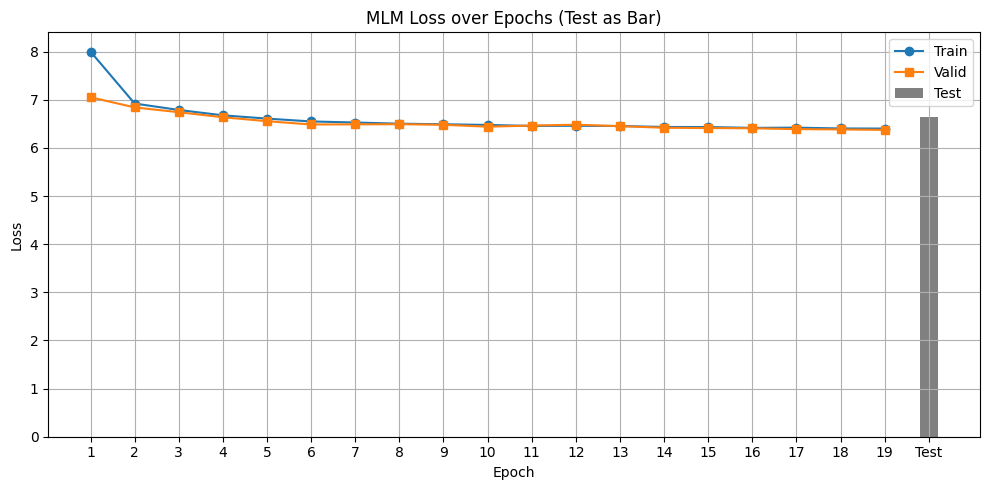

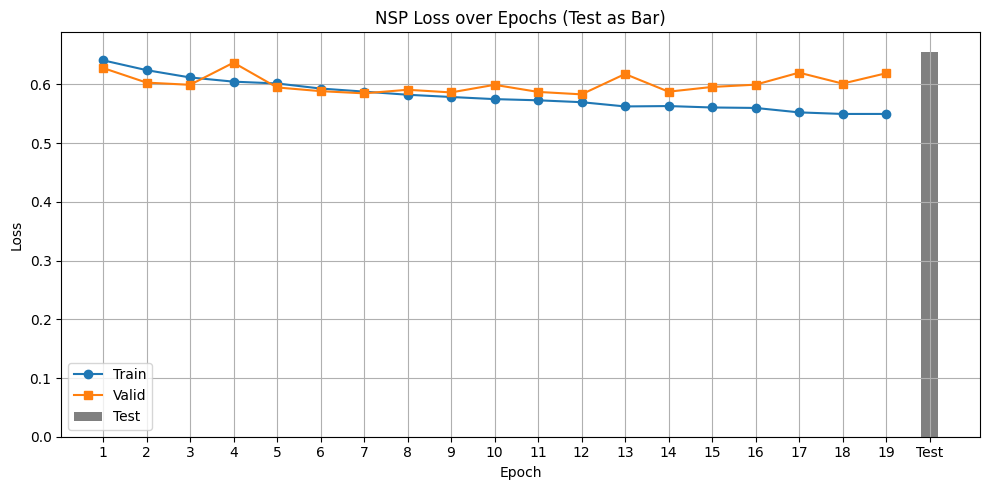

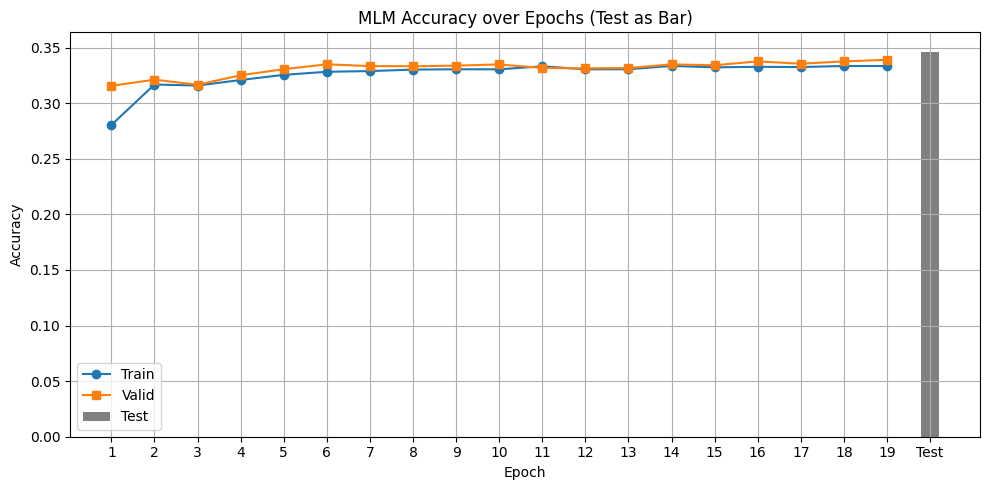

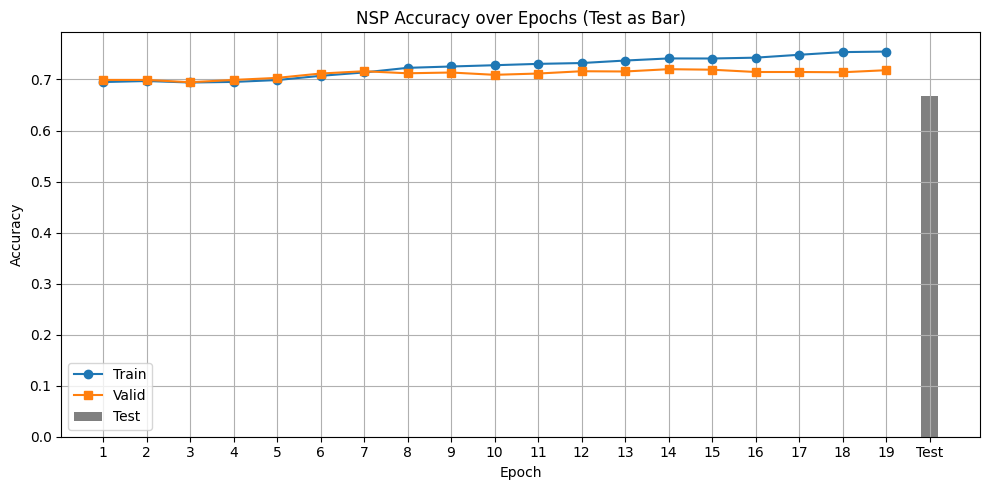

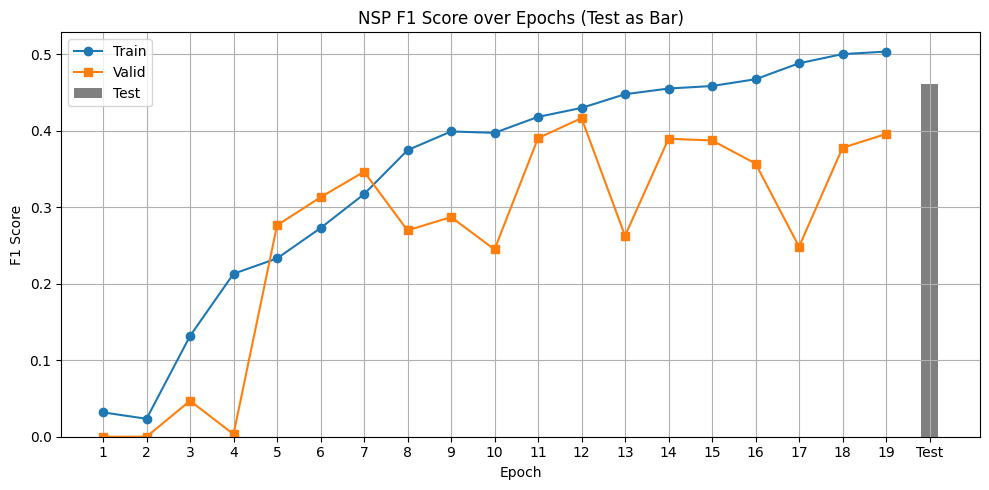

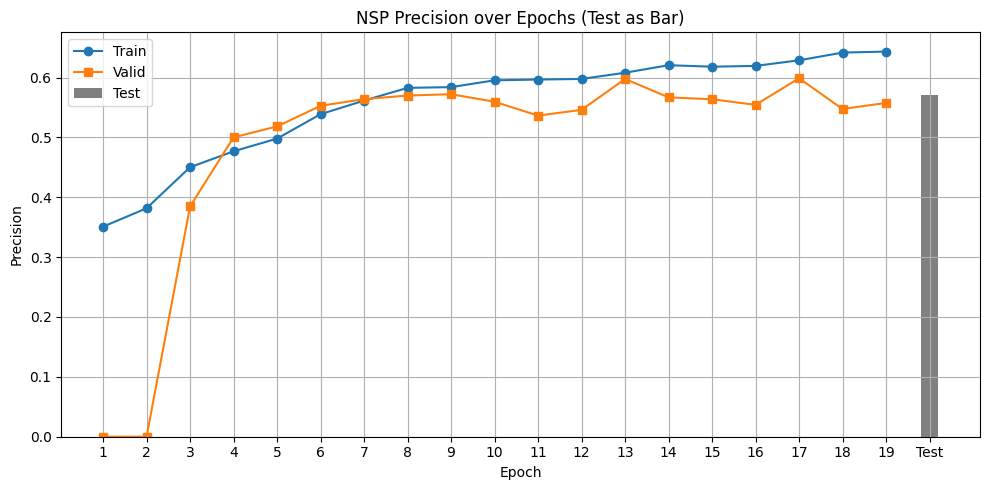

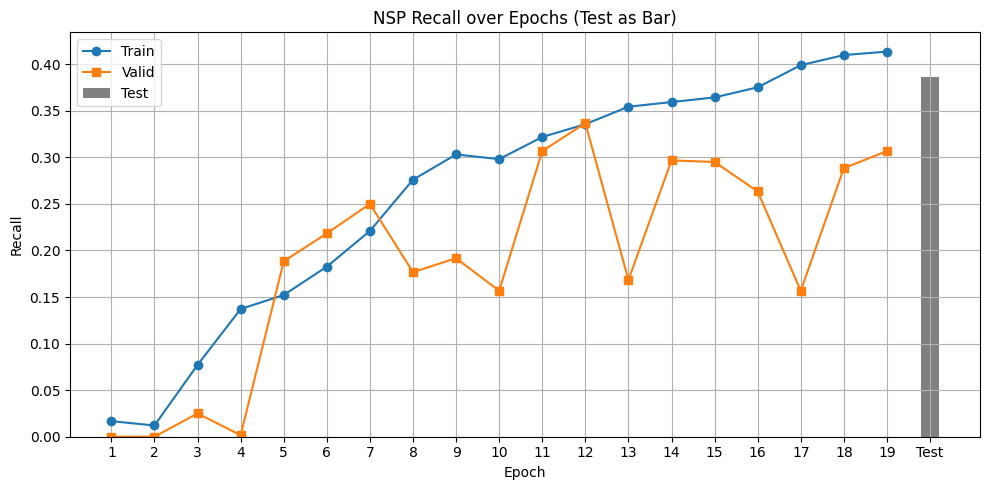

In [ ]:
plot_all_metrics_with_test(bert_results)